In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\sikak\OneDrive\Desktop\HeroVired Assignment\Assignment-3\superstore.csv")

In [3]:
df.head().T

,0,1,2,3,4
Category,Office Supplies,Office Supplies,Office Supplies,Office Supplies,Office Supplies
City,Los Angeles,Los Angeles,Los Angeles,Los Angeles,Los Angeles
Country,United States,United States,United States,United States,United States
Customer.ID,LS-172304,MV-174854,CS-121304,CS-121304,AP-109154
Customer.Name,Lycoris Saunders,Mark Van Huff,Chad Sievert,Chad Sievert,Arthur Prichep
Discount,0.0,0.0,0.0,0.0,0.0
Market,US,US,US,US,US
记录数,1,1,1,1,1
Order.Date,00:00.0,00:00.0,00:00.0,00:00.0,00:00.0
Order.ID,CA-2011-130813,CA-2011-148614,CA-2011-118962,CA-2011-118962,CA-2011-146969


In [4]:
missing_values = df.isnull().sum()
duplicate_rows = df.duplicated().sum()
print("Missing values per column:\n")
print(missing_values)
print("\nDuplicate rows:", duplicate_rows)

Missing values per column:

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     5
State             3
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

Duplicate rows: 0


In [5]:
summary_table = pd.DataFrame({
    "Property": ["Rows", "Columns", "Size"],
    "Value": [df.shape[0], df.shape[1], df.size]
})
print("\nDataset Summary:\n")
print(summary_table)

datatype_table = pd.DataFrame({
    "Feature": df.columns,
    "Datatype": df.dtypes.values
})
print("\nFeature Datatypes:\n")
print(datatype_table)


Dataset Summary:

  Property    Value
0     Rows    51290
1  Columns       27
2     Size  1384830

Feature Datatypes:

           Feature Datatype
0         Category   object
1             City   object
2          Country   object
3      Customer.ID   object
4    Customer.Name   object
5         Discount  float64
6           Market   object
7              记录数    int64
8       Order.Date   object
9         Order.ID   object
10  Order.Priority   object
11      Product.ID   object
12    Product.Name   object
13          Profit  float64
14        Quantity    int64
15          Region   object
16          Row.ID    int64
17           Sales    int64
18         Segment   object
19       Ship.Date   object
20       Ship.Mode   object
21   Shipping.Cost  float64
22           State   object
23    Sub.Category   object
24            Year    int64
25         Market2   object
26         weeknum    int64


In [7]:
print(df.columns)
if '记录数' in df.columns:
    df.drop('记录数', axis=1, inplace=True)
    print("Unknown encoded column deleted successfully")
print(df.columns)

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')
Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')


In [8]:
# Column identification
identifier_cols = ['row_id','order_id','customer_id','product_id','customer_name','product_name']
# Categorical Columns
categorical_cols = ['Category','Sub.Category','City','State','Country','Region','Market','Market2','Segment','Ship.Mode','Order.Priority']
# Numerical Columns
numerical_cols = ['Sales','Profit','Quantity','Shipping.Cost','weeknum','Discount','Year']
# Target Column
target_col = 'Profit'


Univariate Analysis : Sales
count    51290.000000
mean       246.498440
std        487.567175
min          0.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      22638.000000
Name: Sales, dtype: float64


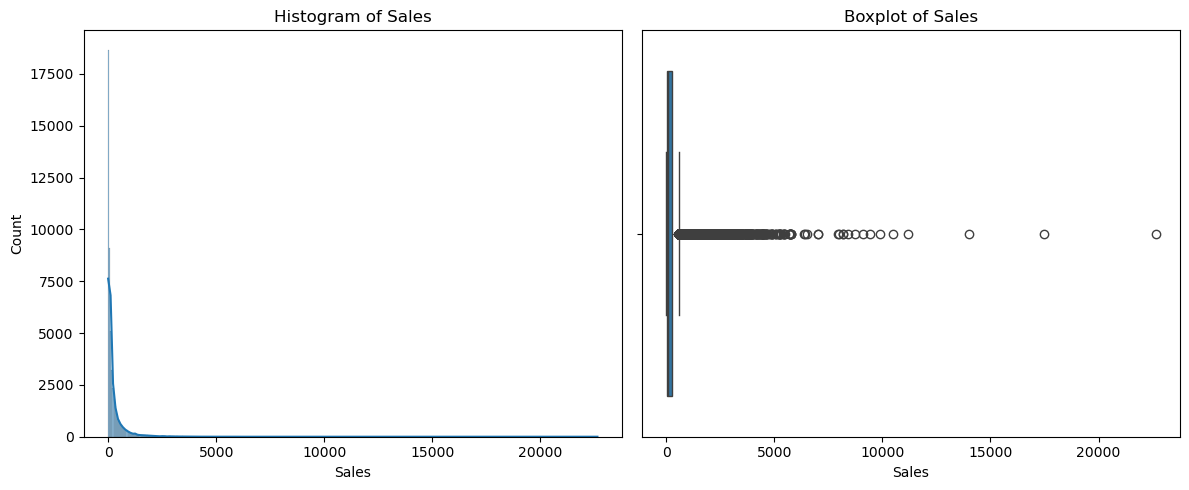


Univariate Analysis : Profit
count    51290.000000
mean        28.610982
std        174.340972
min      -6599.978000
25%          0.000000
50%          9.240000
75%         36.810000
max       8399.976000
Name: Profit, dtype: float64


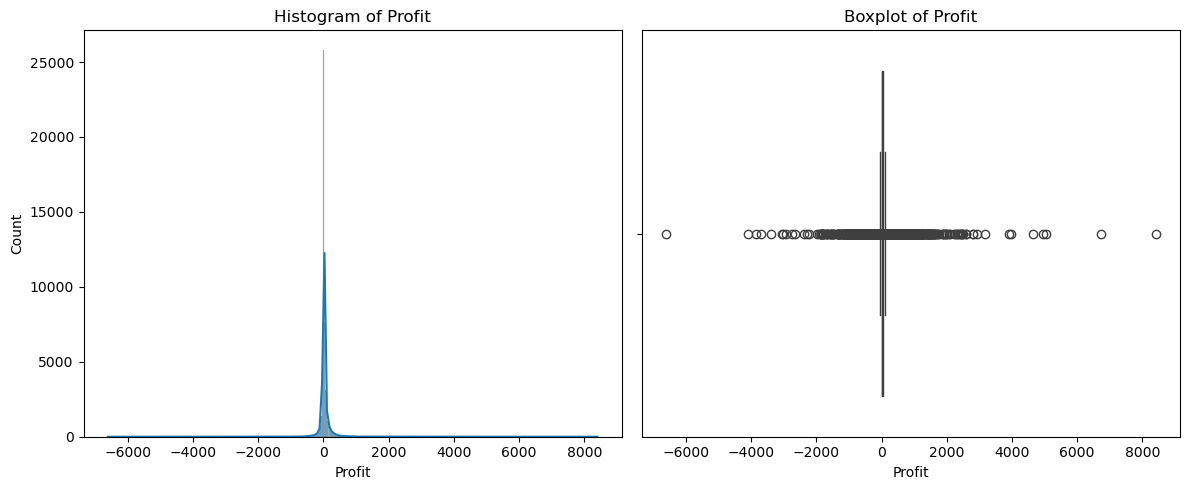


Univariate Analysis : Quantity
count    51290.000000
mean         3.476545
std          2.278766
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         14.000000
Name: Quantity, dtype: float64


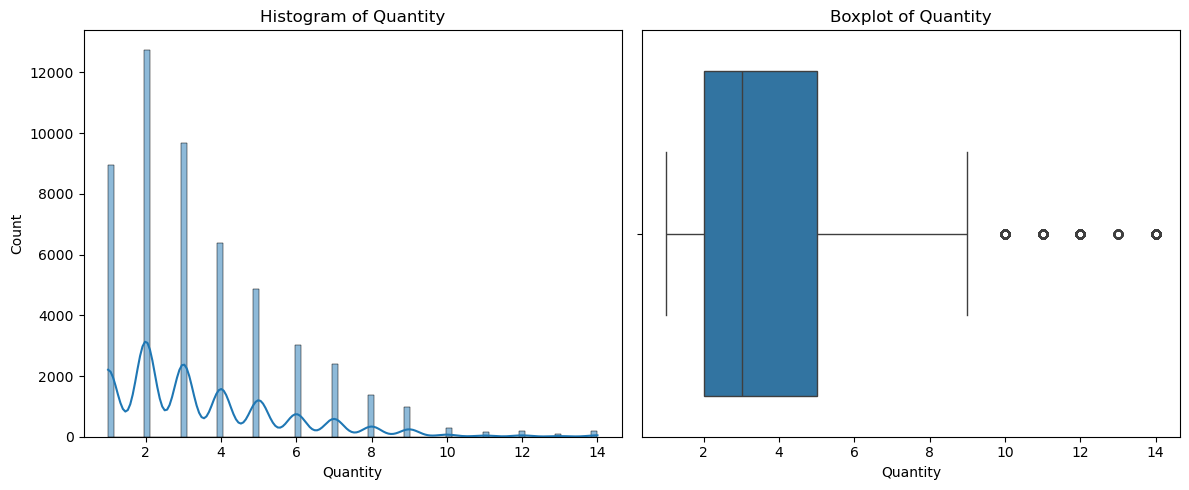


Univariate Analysis : Shipping.Cost
count    51285.000000
mean        26.378062
std         57.299145
min          0.002000
25%          2.610000
50%          7.790000
75%         24.450000
max        933.570000
Name: Shipping.Cost, dtype: float64


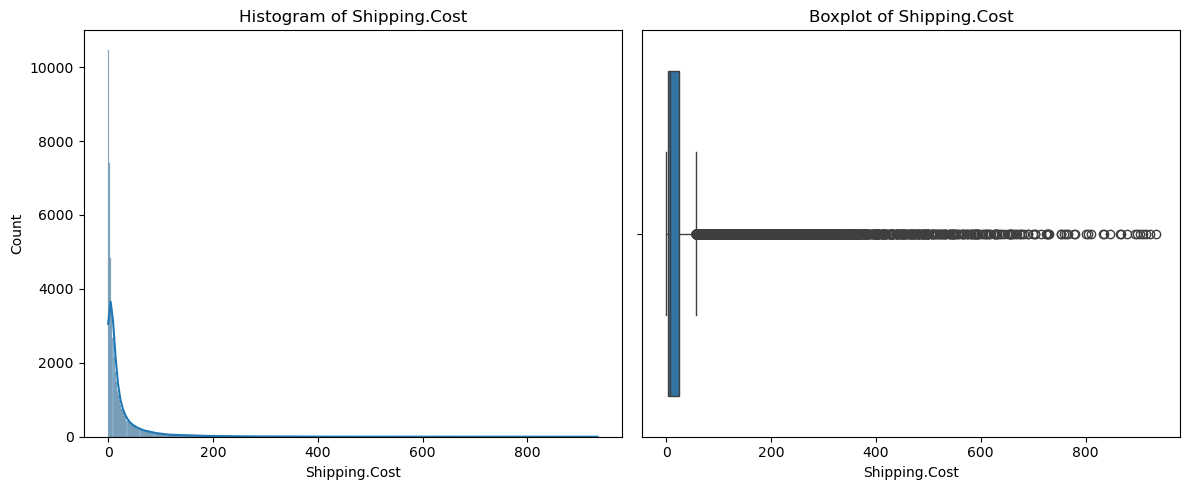


Univariate Analysis : weeknum
count    51290.000000
mean        31.287112
std         14.429795
min          1.000000
25%         20.000000
50%         33.000000
75%         44.000000
max         53.000000
Name: weeknum, dtype: float64


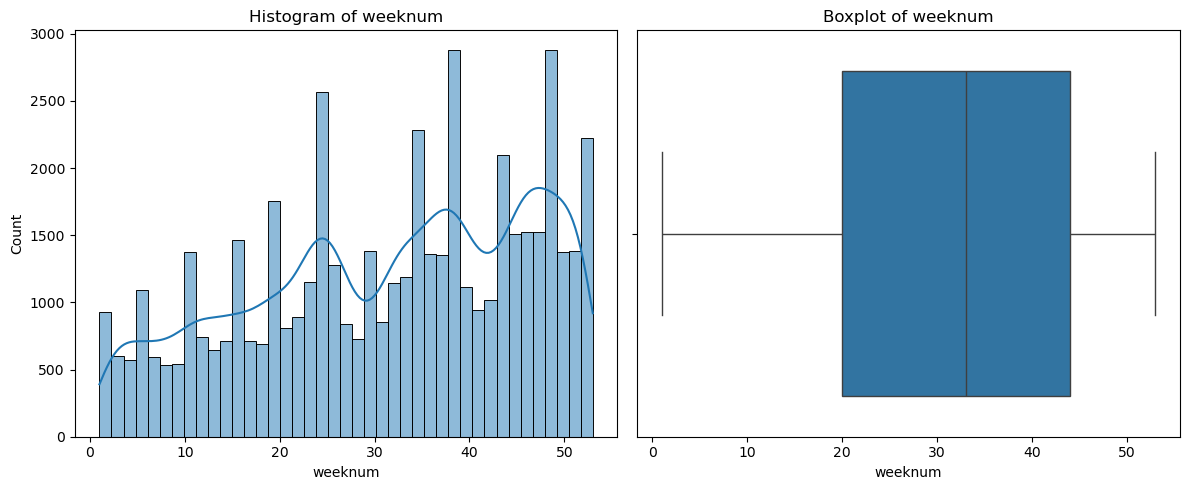


Univariate Analysis : Discount
count    51290.000000
mean         0.142908
std          0.212280
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max          0.850000
Name: Discount, dtype: float64


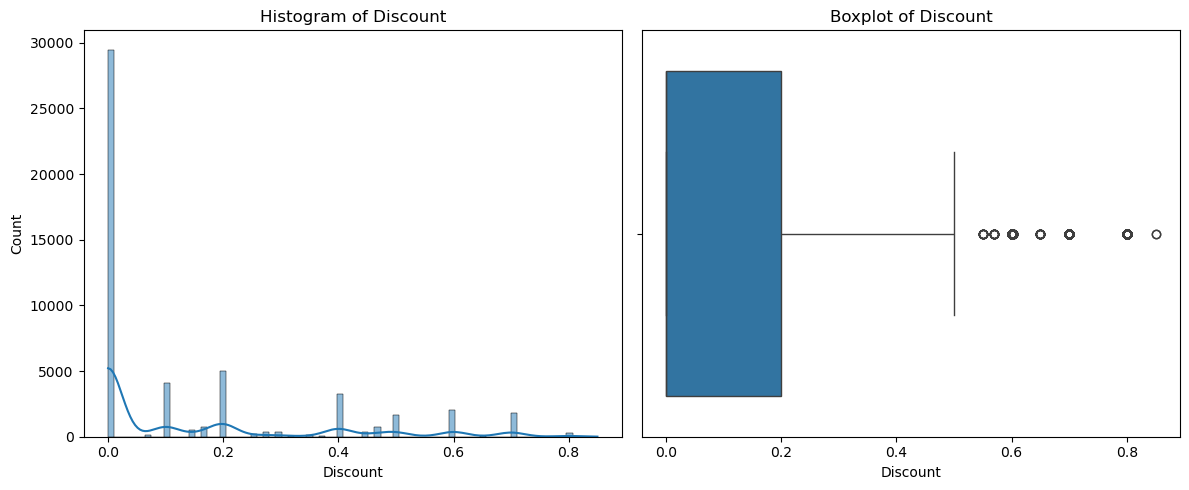


Univariate Analysis : Year
count    51290.000000
mean      2012.777208
std          1.098931
min       2011.000000
25%       2012.000000
50%       2013.000000
75%       2014.000000
max       2014.000000
Name: Year, dtype: float64


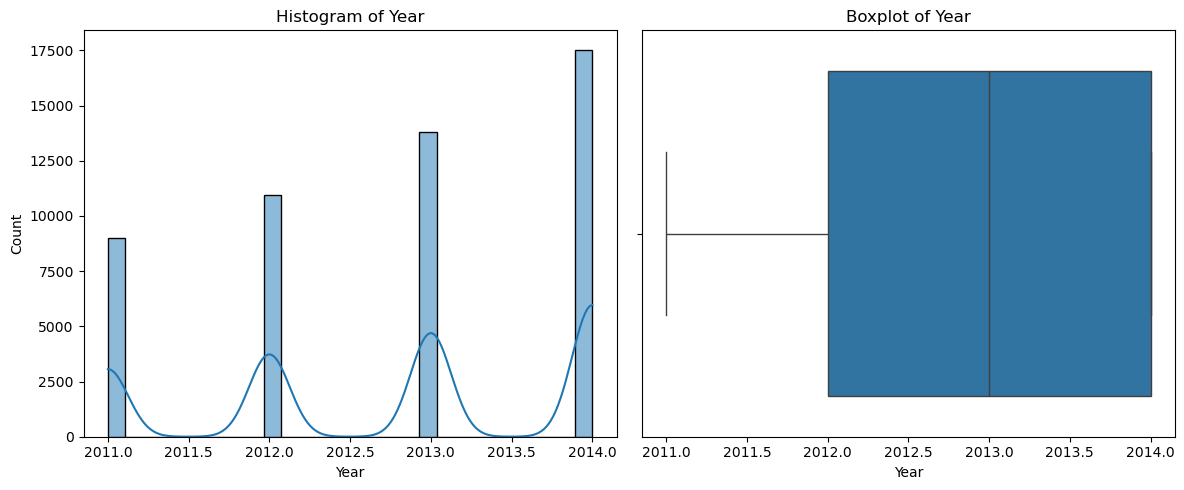

In [9]:
for col in numerical_cols:
    print(f"\n{'='*50}")
    print(f"Univariate Analysis : {col}")
    print(f"{'='*50}")
    print(df[col].describe())
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

In [ ]:
# Which features seem useless in the analysis? Explain why? 
# Year: the histogram contains only limited unique values,most data belongs to only few years and it is only used for time-based analysis
# weeknum: Week numbers are evenly spread.Alone,they do not explain customer or sales behavior.
#it contians only week numbers, it may used for times -series analysis

In [10]:
#Which features are uniformly distributed or normally distributed?
# By obsevering the graphs no column is uniformaly distributes / normal distributed ,but
#Discount → Nearly Uniformly Distributed.
#The histogram bars are spread relatively evenly across different discount values.No strong peak or heavy concentration is visible.
#Discounts are applied across multiple ranges fairly consistently.Indicates balanced discount strategies in the business.

In [11]:
#Which features are right-skewed/left-skewed? What does this signify? 
# Right-Skewed Features: sales, profit & shipping .
# Signifies
#Majority of transactions are small or medium-sized.
# A small number of orders generate very high sales or profit.
# Indicates existence of premium customers or bulk purchases.
# High shipping costs may represent international or urgent deliveries.
#Left - Skewed features: Discount
# Higher discount values occur more frequently.
# Lower discounts are comparatively less common.

In [12]:
# Which features have a high number of outliers, and discuss the impact
# sales,profit & shipping.cost has high number of outliers
# Affects Average Values
# Impacts Statistical Analysis
#Outliers may represent: High-value customers ,Bulk orders ,Expensive shipping regions
#Exceptional profitable transactions


Categorical Feature : Category
Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


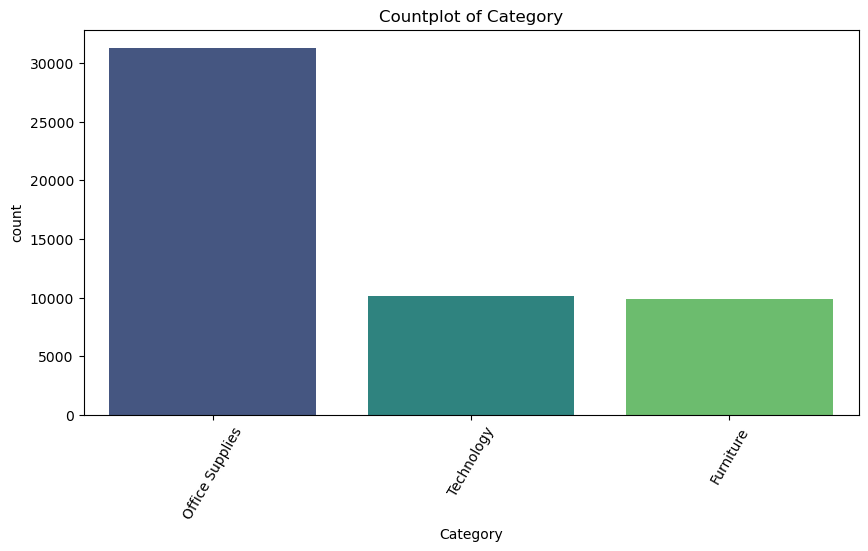


Categorical Feature : Sub.Category
Sub.Category
Binders        6152
Storage        5059
Art            4883
Paper          3538
Chairs         3434
Phones         3357
Furnishings    3170
Accessories    3075
Labels         2606
Envelopes      2435
Supplies       2425
Fasteners      2420
Bookcases      2411
Copiers        2223
Appliances     1755
Machines       1486
Tables          861
Name: count, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


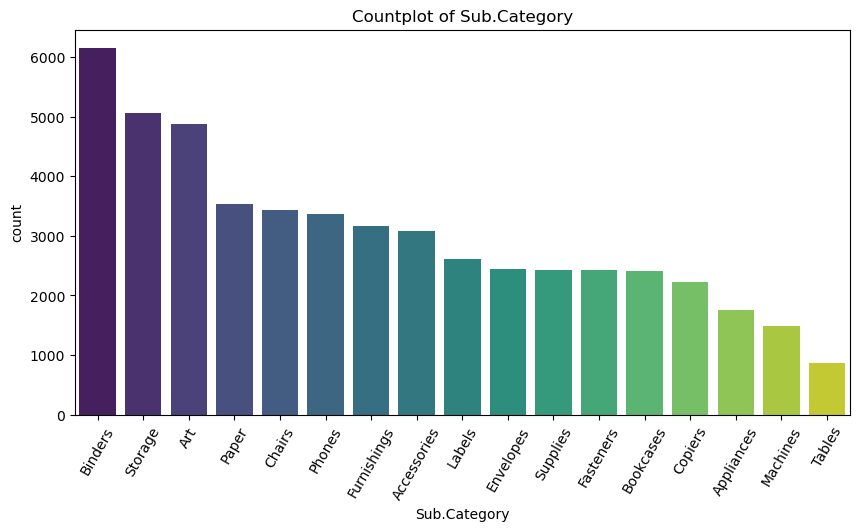


Categorical Feature : City
City
New York City            915
Los Angeles              747
Philadelphia             537
San Francisco            510
Santo Domingo            443
                        ... 
Hadera                     1
Morley                     1
Villeneuve-la-Garenne      1
Torremolinos               1
Redwood City               1
Name: count, Length: 3636, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


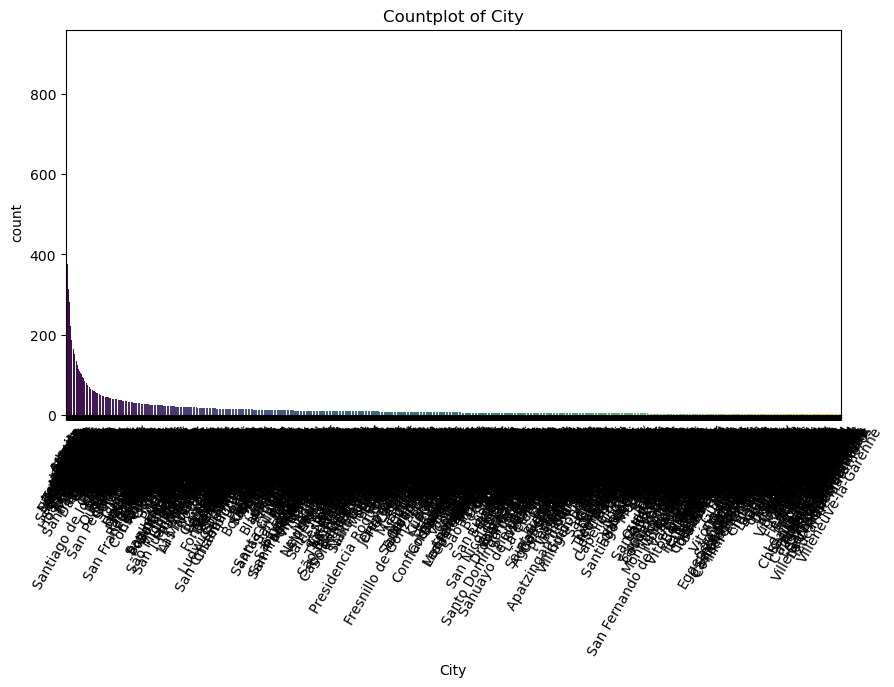


Categorical Feature : State
State
California       2001
England          1499
New York         1128
Texas             985
Ile-de-France     981
                 ... 
Yevrey              1
Vrancea             1
Stara Zagora        1
Paysandú            1
Wyoming             1
Name: count, Length: 1094, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


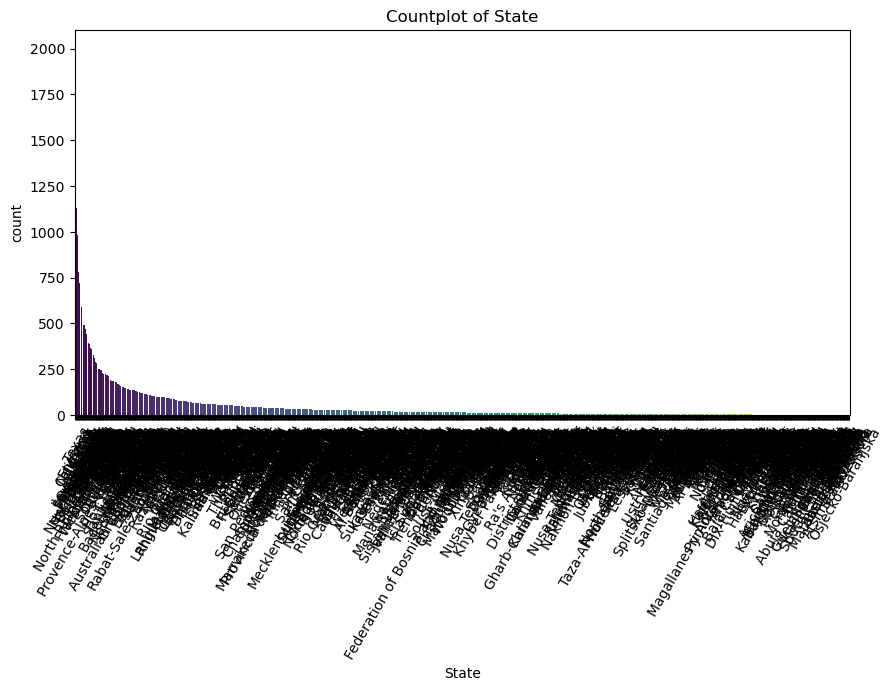


Categorical Feature : Country
Country
United States    9994
Australia        2837
France           2827
Mexico           2644
Germany          2065
                 ... 
South Sudan         2
Chad                2
Swaziland           2
Eritrea             2
Bahrain             2
Name: count, Length: 147, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


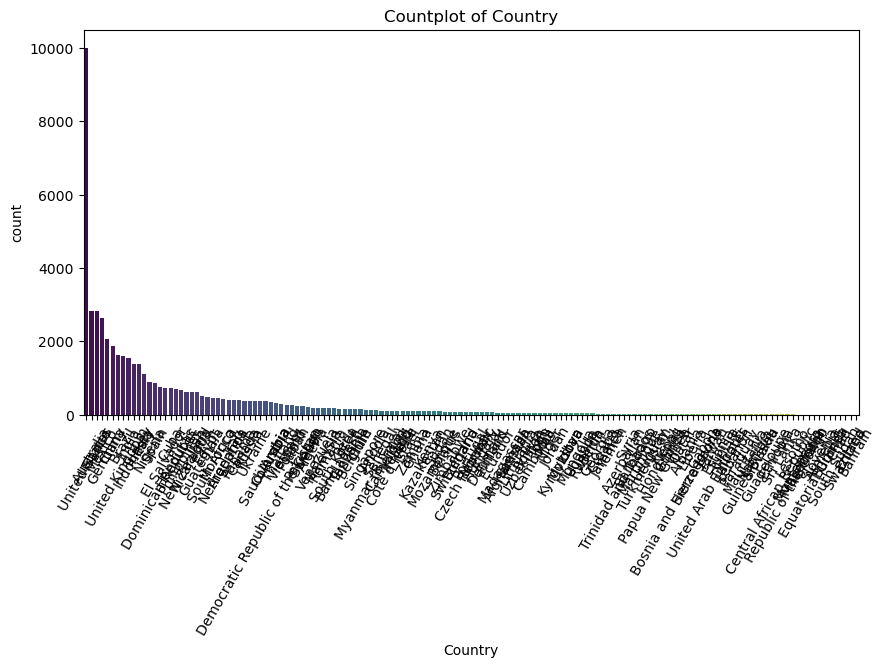


Categorical Feature : Region
Region
Central           11117
South              6645
EMEA               5029
North              4785
Africa             4587
Oceania            3487
West               3203
Southeast Asia     3129
East               2848
North Asia         2338
Central Asia       2048
Caribbean          1690
Canada              384
Name: count, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


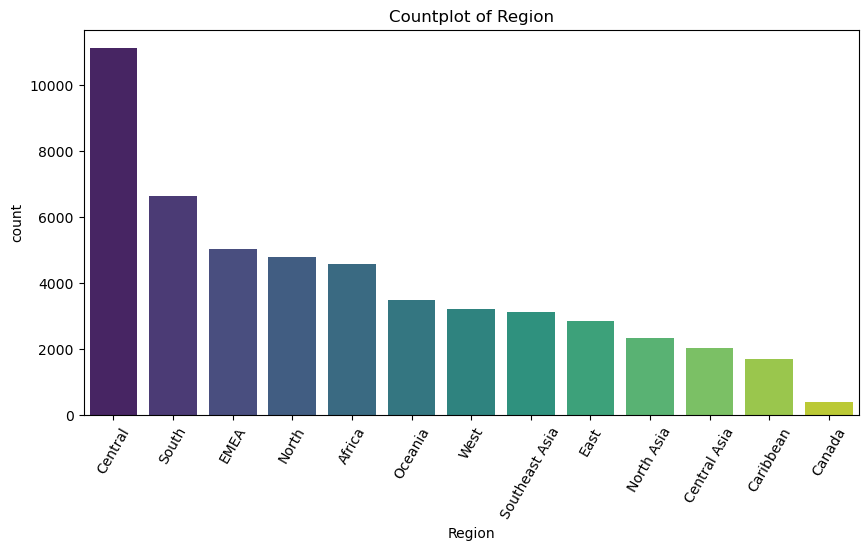


Categorical Feature : Market
Market
APAC      11002
LATAM     10294
EU        10000
US         9994
EMEA       5029
Africa     4587
Canada      384
Name: count, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


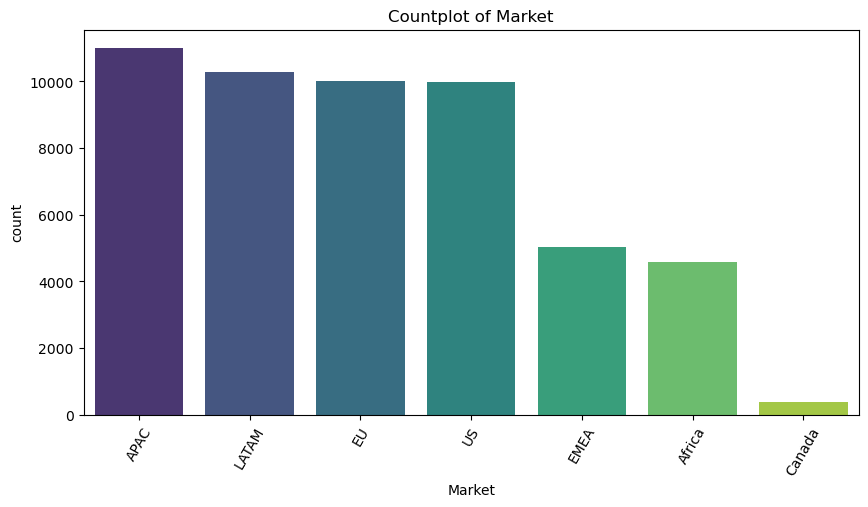


Categorical Feature : Market2
Market2
APAC             11002
North America    10378
LATAM            10294
EU               10000
EMEA              5029
Africa            4587
Name: count, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


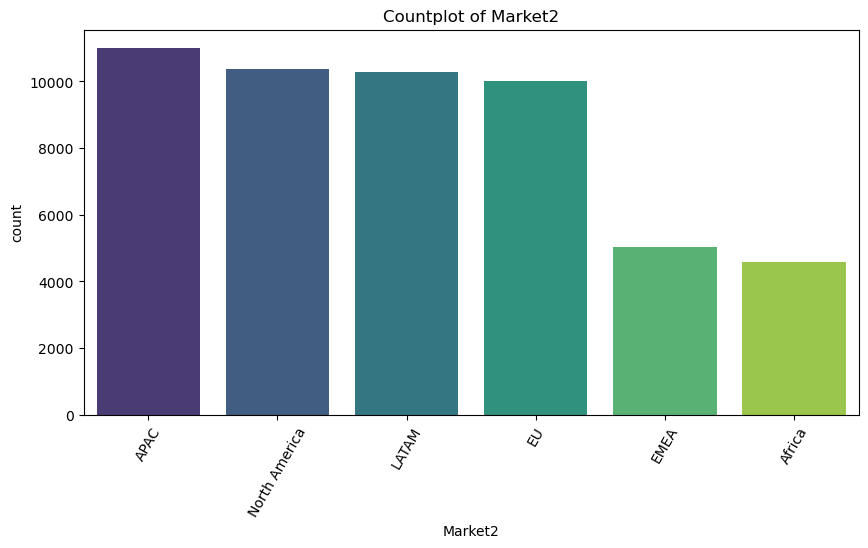


Categorical Feature : Segment
Segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


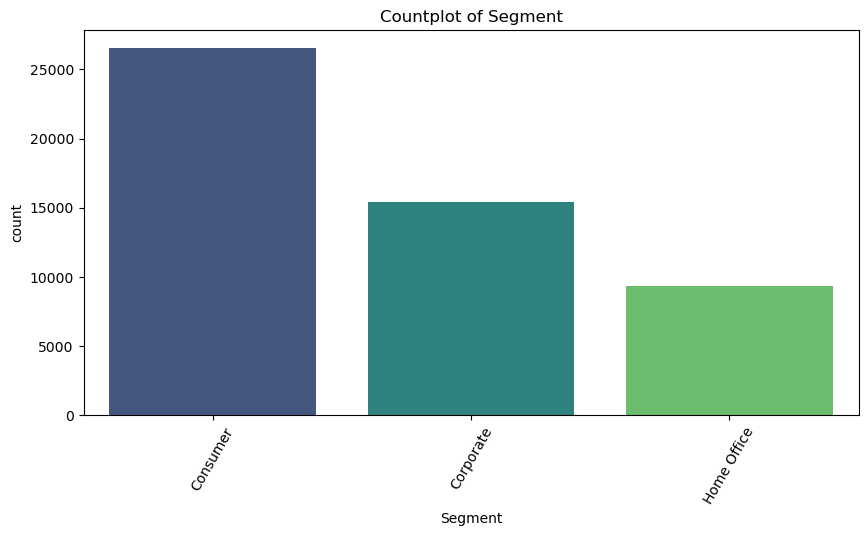


Categorical Feature : Ship.Mode
Ship.Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


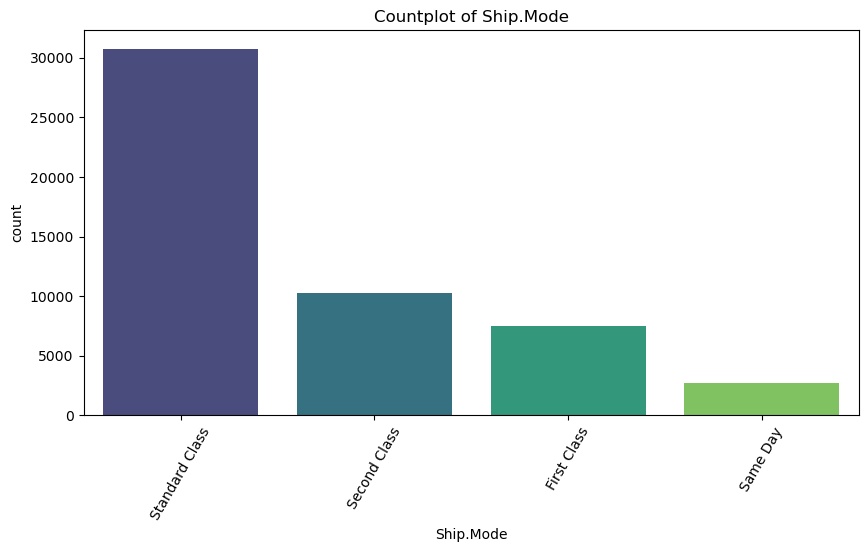


Categorical Feature : Order.Priority
Order.Priority
Medium      29433
High        15501
Critical     3932
Low          2424
Name: count, dtype: int64


C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\1244176457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')


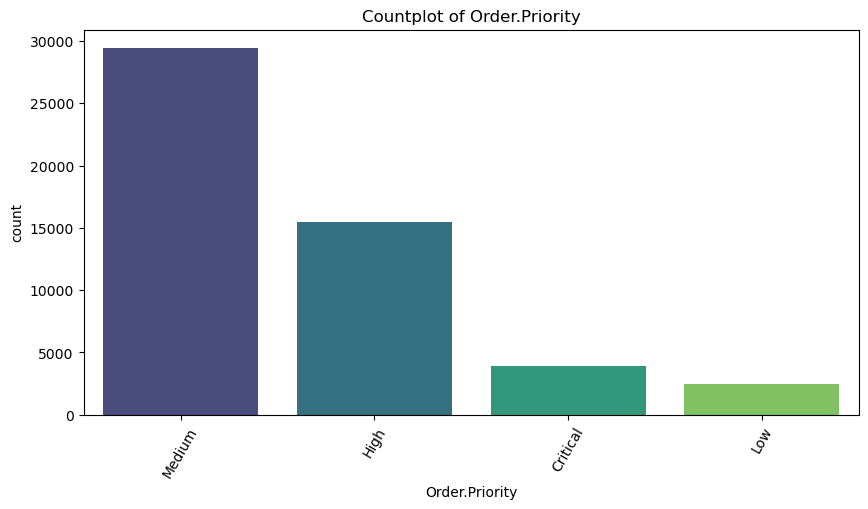

In [16]:
# univariant analysis on categorial_cols
for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"Categorical Feature : {col}")
    print(f"{'='*50}")
    print(df[col].value_counts())
    # Plot Countplot
    plt.figure(figsize=(10,5))
    sns.countplot(x=df[col],order=df[col].value_counts().index ,palette='viridis')
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=60)
    plt.show()

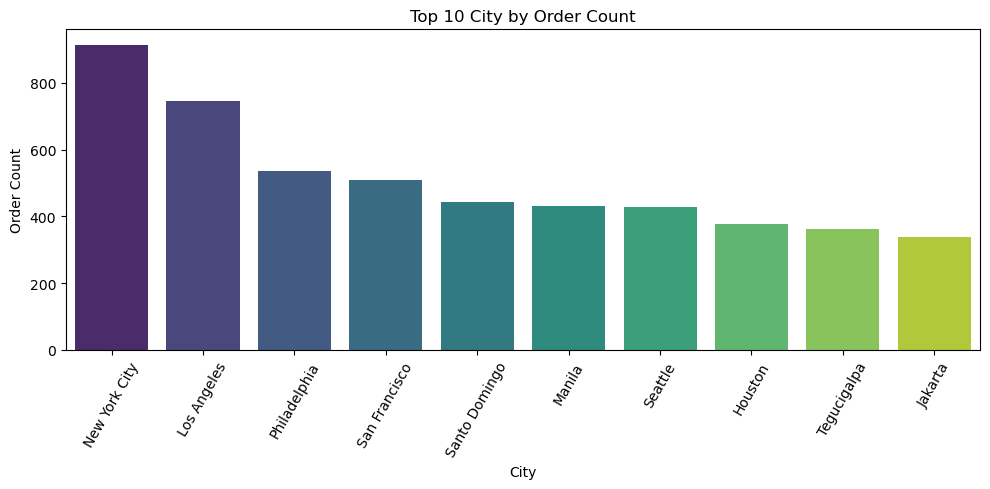

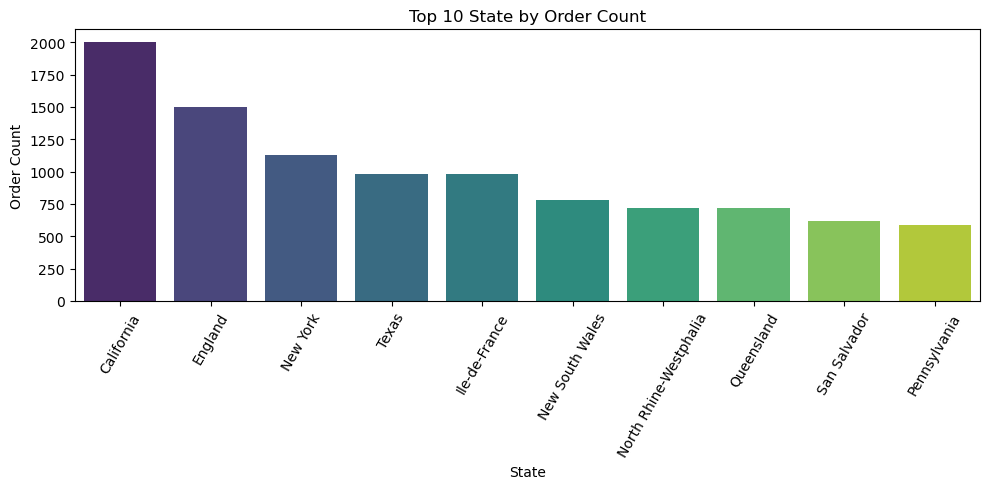

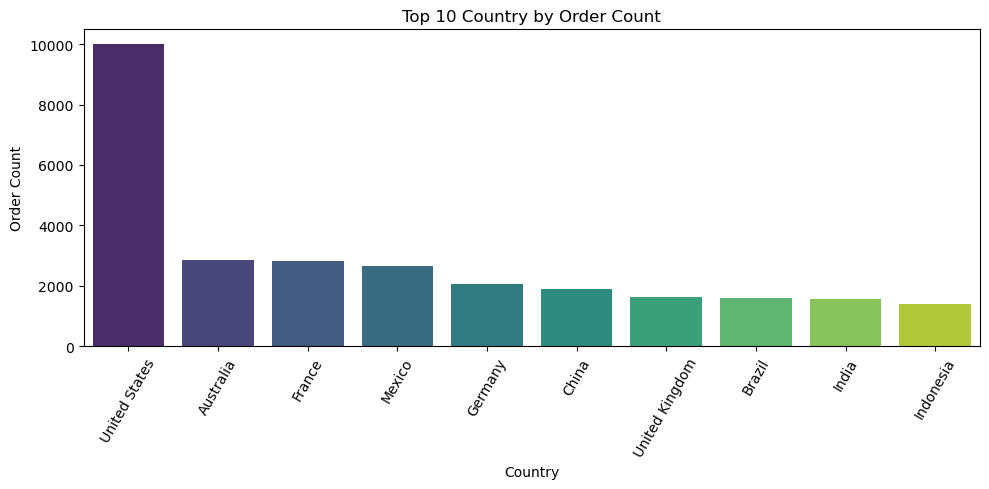

In [18]:
top_cols = ['City', 'State', 'Country']
for col in top_cols:
    top_10 = df[col].value_counts().head(10)
    plt.figure(figsize=(10,5))
    sns.barplot(
        x=top_10.index,
        y=top_10.values,
        hue=top_10.index,
        palette='viridis',
        legend=False
    )
    plt.title(f'Top 10 {col} by Order Count')
    plt.xlabel(col)
    plt.ylabel('Order Count')
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()

In [19]:
# Which features seem inaccurate and are not useful as categorical “insights” directly
# state,city & country contains too many values, Visualization becomes overcrowded and difficult to interpret
# for analysis we can take top-N or customer segmentation for better use

In [20]:
#What’s the issue with treating Customer? Name as a categorical feature for modeling?
#Customer.Name contains a very large number of unique values.
#Most customers appear only a few times.
# It may increases model complexity

In [21]:
# Is the Category distribution balanced or skewed? Give a 1-line reason. 
#Category distribution is slightly skewed as some categories have significantly higher order counts than others rather than being evenly distributed.
# it may because of certain product categories are more popular and generate significantly more orders than others.

In [22]:
# In Country, does one country dominate strongly? What does that imply about geographic bias?
# The United States contributes the highest number of orders (~19.5%), indicating a moderate geographic bias toward the U.S., 
# though the dataset remains fairly diverse across 147 countries

In [23]:
#Is the City dataset concentrated in a few cities or spread out
# The Top 10 City bar chart shows a steep decline after the leading cities
# small number of cities account for a large share of transactions
# City dataset is concentrated in a few cities, as the top cities contribute a significantly larger number of orders compared to most other cities, 
# which have relatively low transaction counts

C:\Users\sikak\AppData\Local\Temp\ipykernel_19860\910840075.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


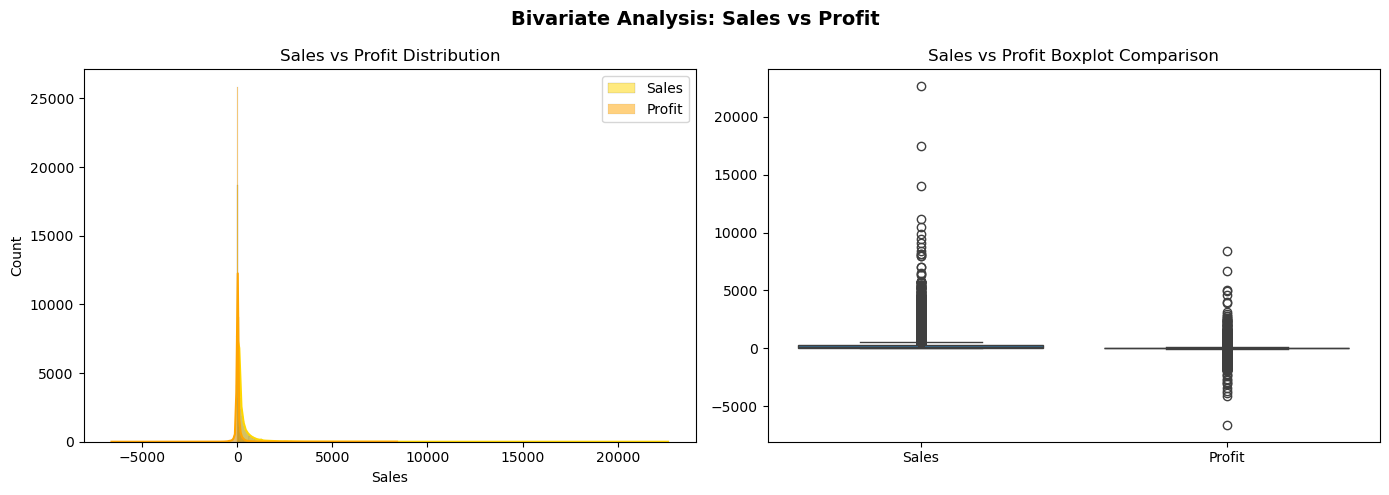

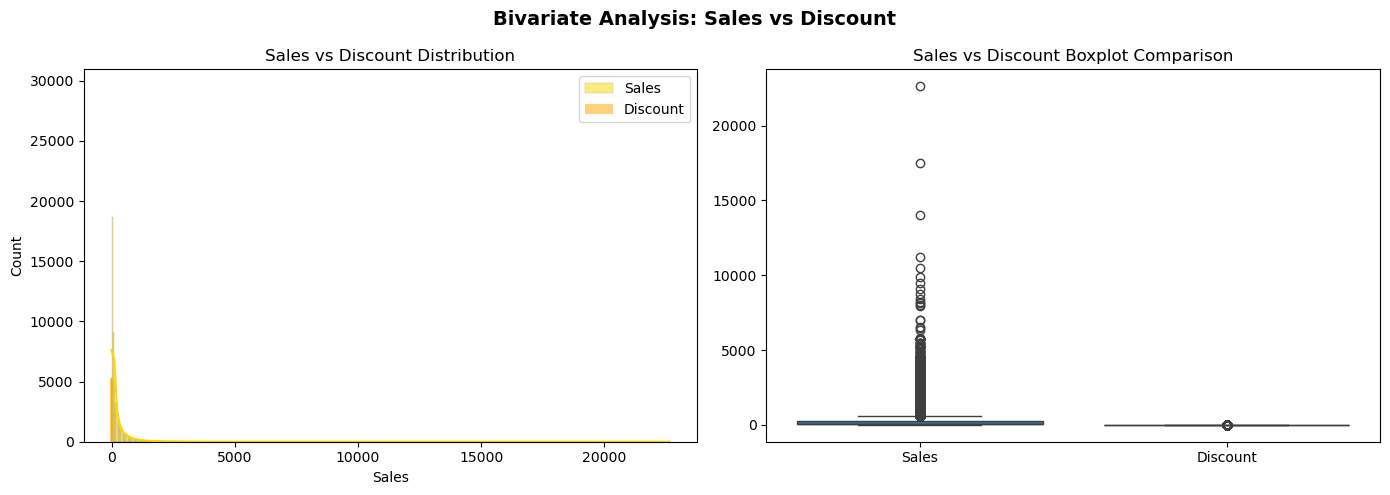

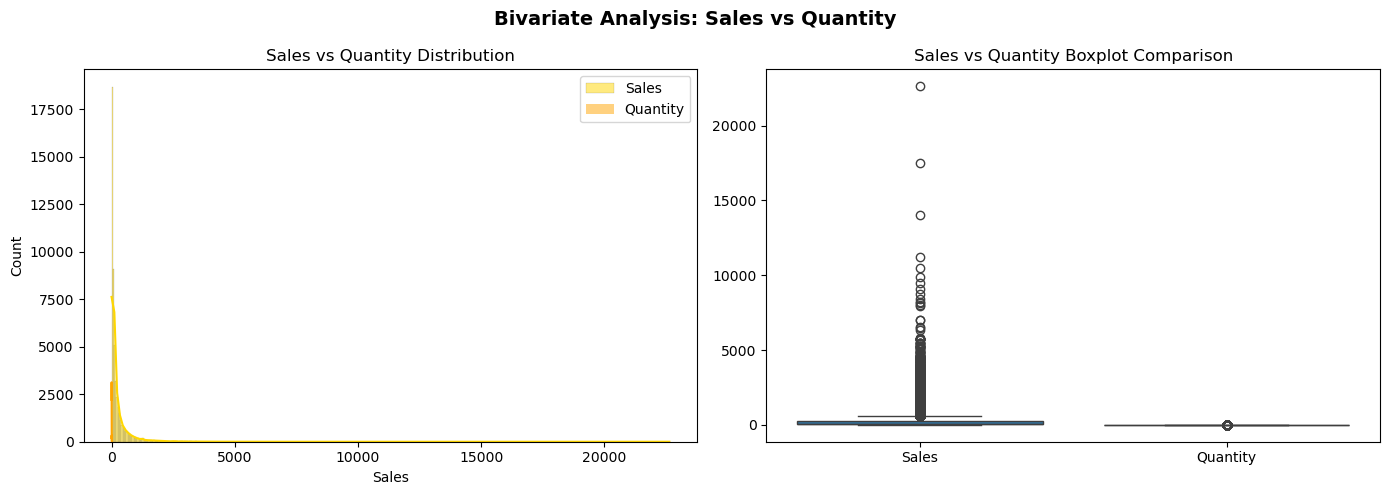

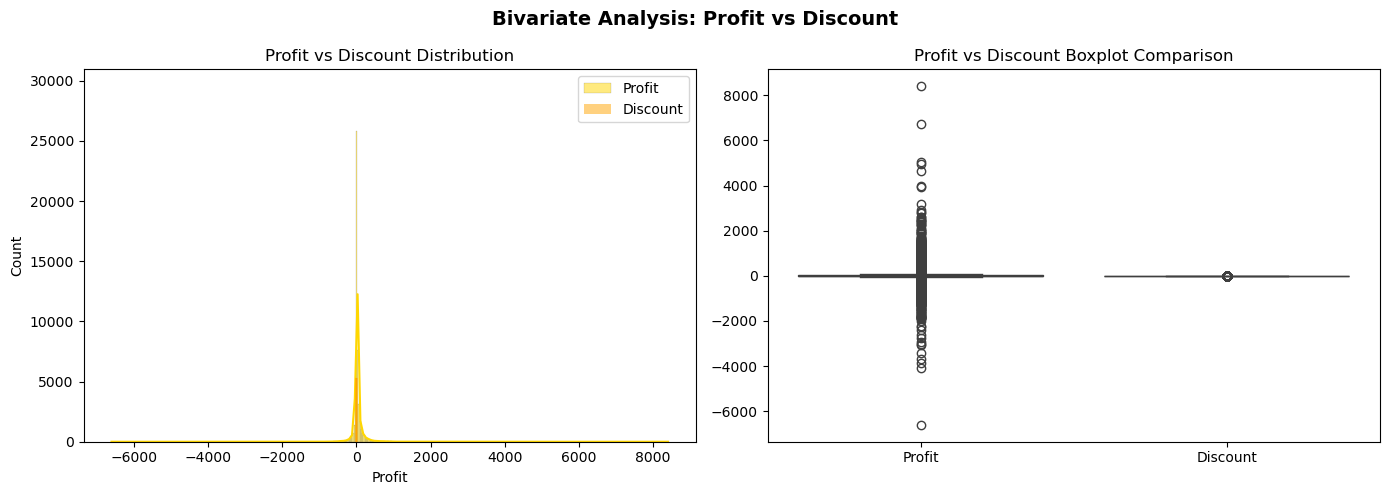

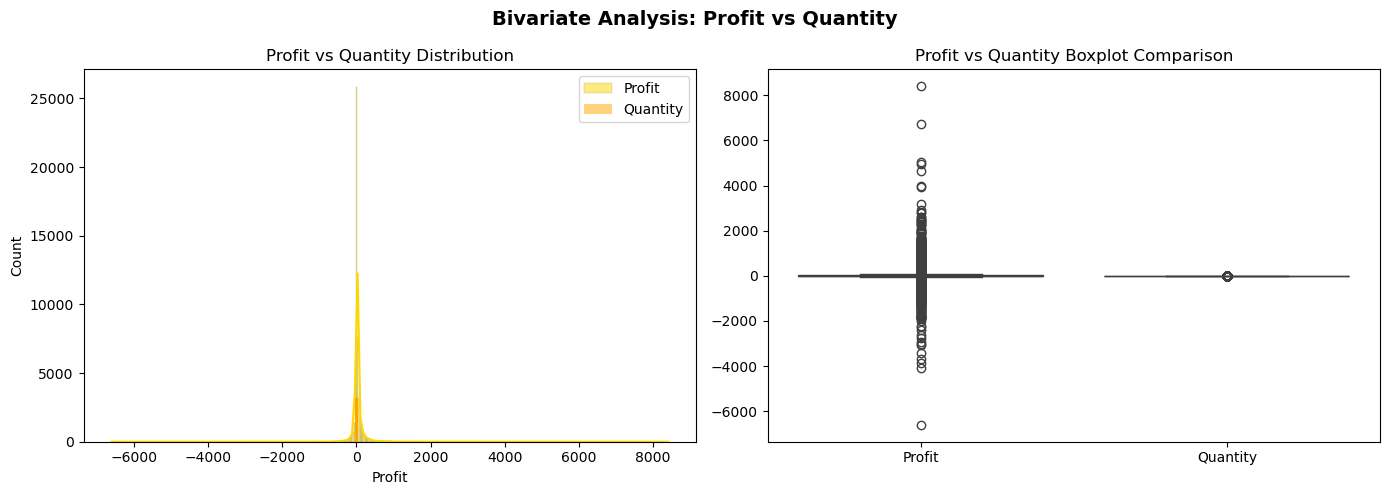

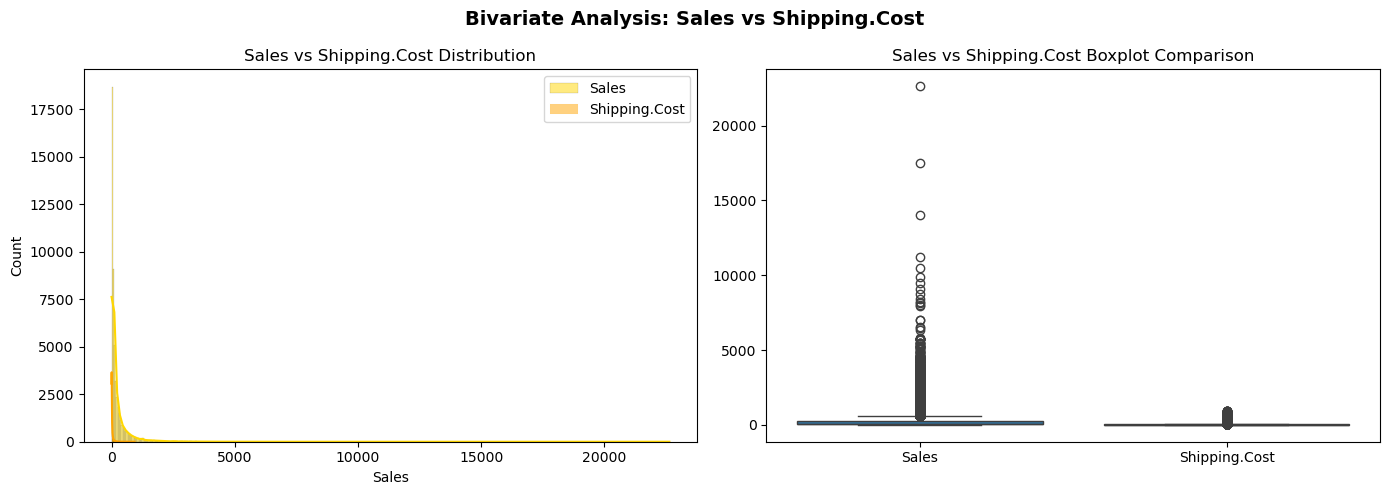

In [24]:
#Bivariant Analysis for numerical-to-numerical
pairs = [
    ('Sales', 'Profit'),
    ('Sales', 'Discount'),
    ('Sales', 'Quantity'),
    ('Profit', 'Discount'),
    ('Profit', 'Quantity'),
    ('Sales', 'Shipping.Cost')
]

for x, y in pairs:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Overlapping Histogram
    sns.histplot(df[x],
                 kde=True,
                 color='gold',
                 alpha=0.5,
                 label=x,
                 ax=axes[0])

    sns.histplot(df[y],
                 kde=True,
                 color='orange',
                 alpha=0.5,
                 label=y,
                 ax=axes[0])

    axes[0].set_title(f'{x} vs {y} Distribution')
    axes[0].legend()

    # Double Boxplot
    sns.boxplot(data=df[[x, y]], ax=axes[1])

    axes[1].set_title(f'{x} vs {y} Boxplot Comparison')

    plt.suptitle(f'Bivariate Analysis: {x} vs {y}',
                 fontsize=14,
                 fontweight='bold')

    plt.tight_layout()
    plt.show()

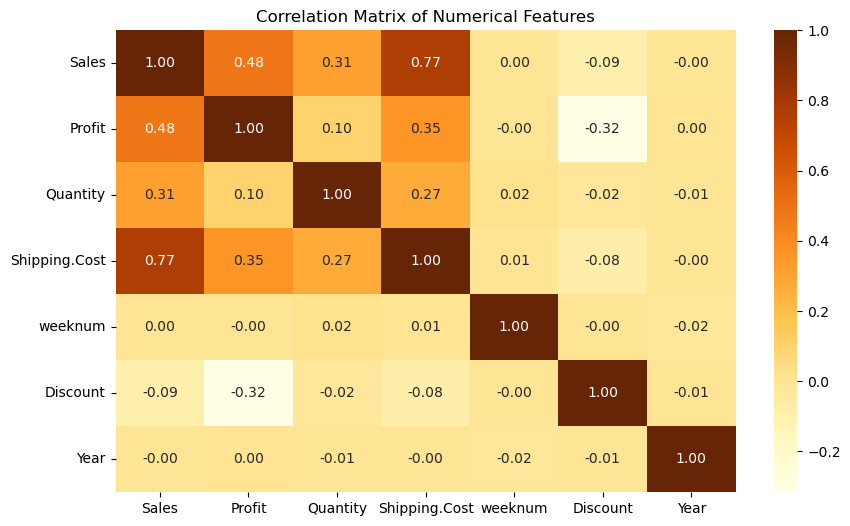

In [25]:
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='YlOrBr',
    fmt='.2f'
)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [26]:
# Which two features are most strongly correlated
#Sales and Shipping.Cost have the strongest correlation.
# Correlation Coefficient is ~ 0.77

In [27]:
# Also name features that are negatively correlated.
#Profit and Discount ~ -0.32
# Sales And Discount ~ -0.09
# Quantity ↔ Discount ~ 0.08
# among all the features Profit and Discount show the strongest negative correlation, 
#suggesting that increasing discounts tends to decrease overall profitability.

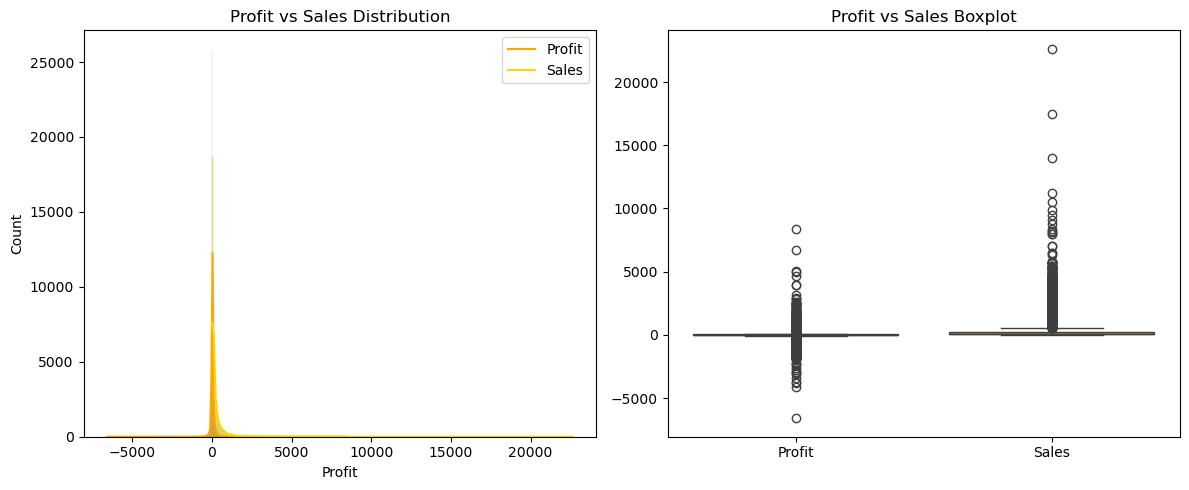

In [28]:
# Profit Vs Sales
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Profit'], color='orange', kde=True, alpha=0.5)
sns.histplot(df['Sales'], color='gold', kde=True, alpha=0.5)
plt.title('Profit vs Sales Distribution')
plt.legend(['Profit','Sales'])
plt.subplot(1,2,2)
sns.boxplot(data=df[['Profit','Sales']])
plt.title('Profit vs Sales Boxplot')
plt.tight_layout()
plt.show()

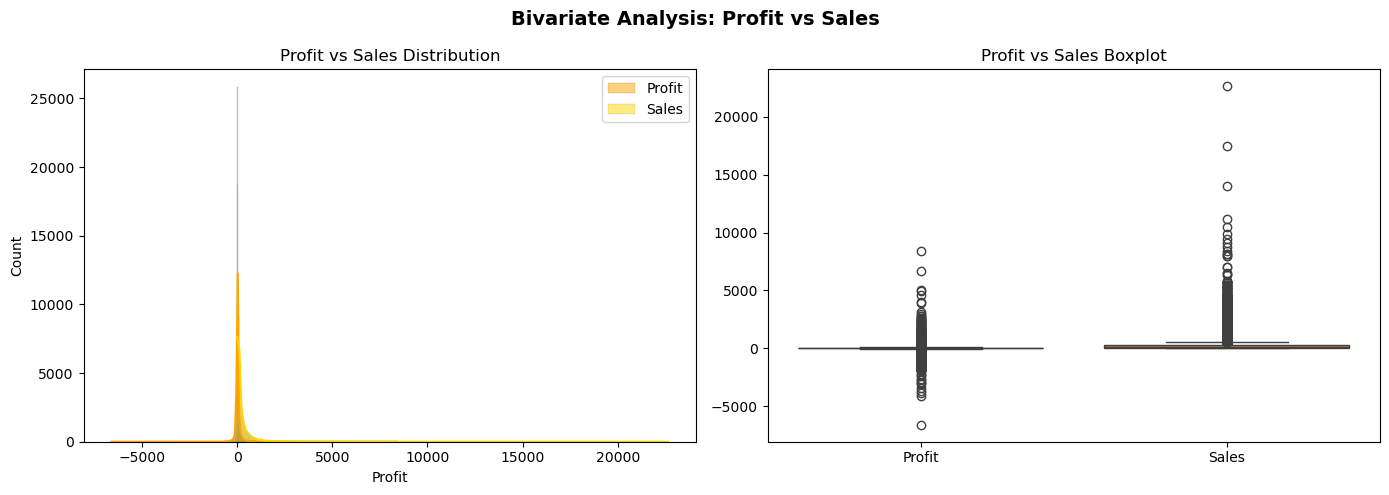

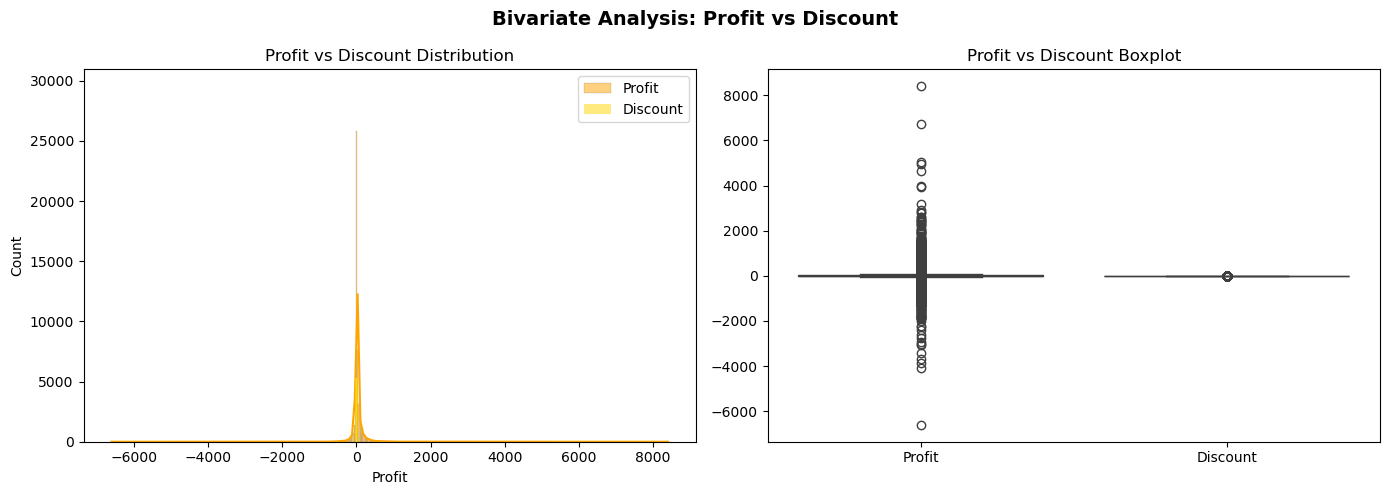

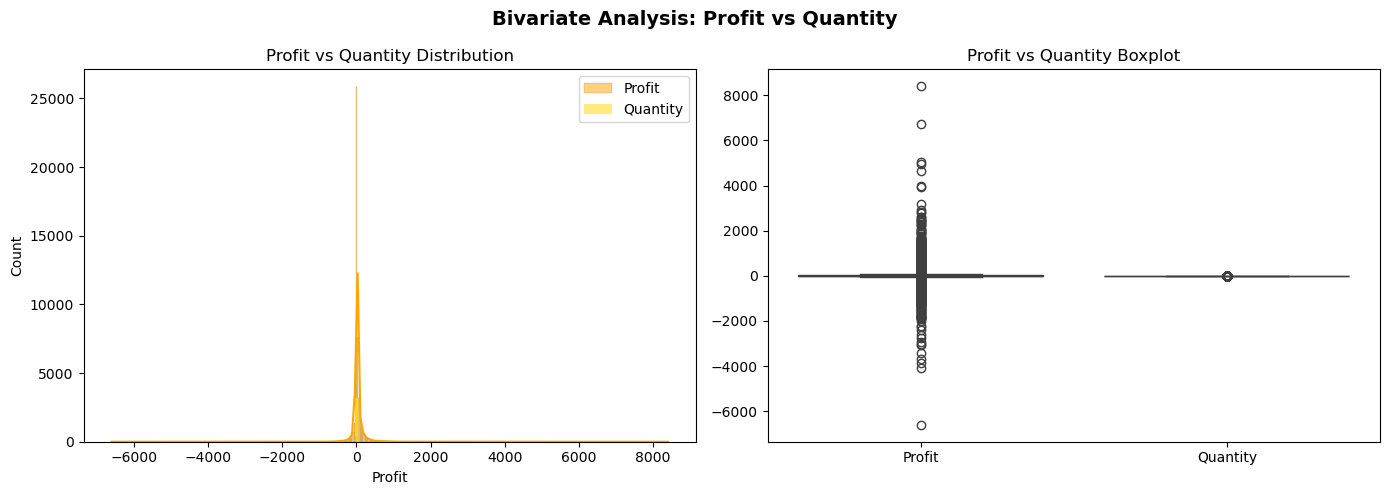

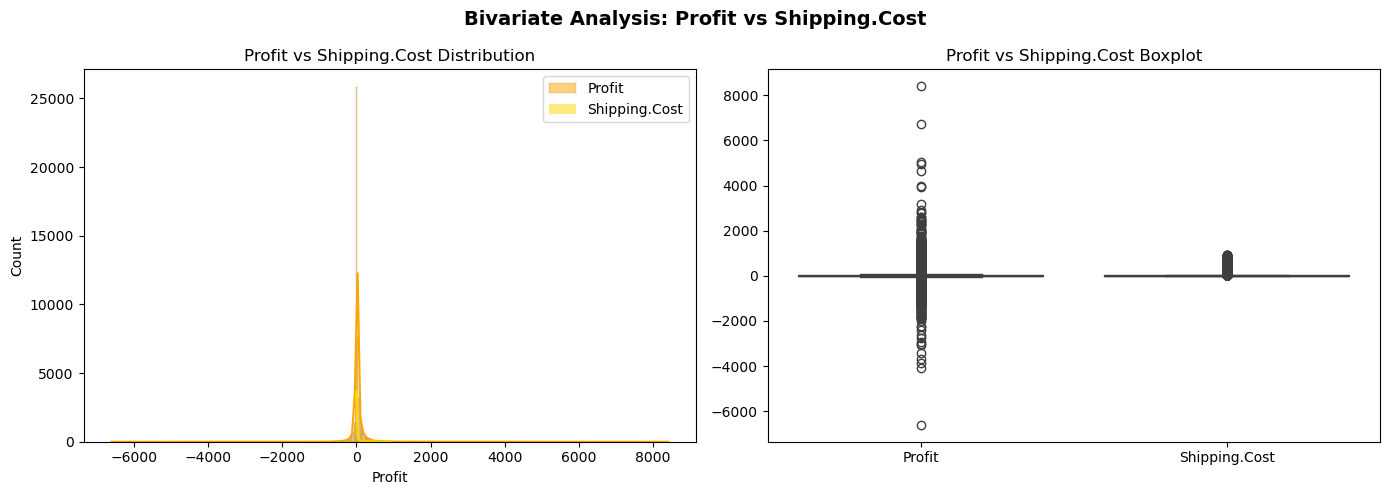

In [29]:
profit_features = [
    'Sales',
    'Discount',
    'Quantity',
    'Shipping.Cost'
]
for feature in profit_features:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    sns.histplot(
        df['Profit'],
        kde=True,
        alpha=0.5,
        color='orange',
        label='Profit',
        ax=axes[0]
    )
    sns.histplot(
        df[feature],
        kde=True,
        alpha=0.5,
        color='gold',
        label=feature,
        ax=axes[0]
    )
    axes[0].set_title(f'Profit vs {feature} Distribution')
    axes[0].legend()
    sns.boxplot(
        data=df[['Profit', feature]],
        ax=axes[1]
    )

    axes[1].set_title(f'Profit vs {feature} Boxplot')
    plt.suptitle(
        f'Bivariate Analysis: Profit vs {feature}',
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

In [30]:
# If your goal is to understand profit, which are the most useful next bivariate checks?Perform them and give clear insights.
# Profit vs Sales, Profit vs Discount, Profit vs Shipping.cost, profit vs Quantity
# Profit vs Sales --Positive relationship observe, higher sales generally contribute to higher profit.
# Profit vs Discount--Negative relationship observed, higher discounts reduce profitability.
# Profit vs Quantity--Weak to moderate relationship,larger quantities do not always guarantee higher profits.
# Profit vs Shipping.Cost ---Moderate positive relationship,higher-value orders often incur higher shipping costs, affecting margins.

In [31]:
# Look for Time Effects Clues. Mention any information you find about the time relationship with any feature.

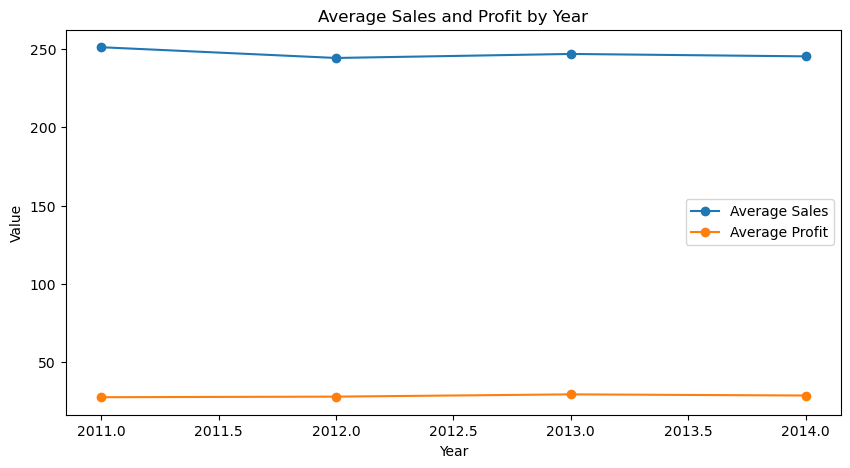

In [32]:
# Sales and Profit by Year
year_metrics = df.groupby('Year')[['Sales', 'Profit']].mean().reset_index()
plt.figure(figsize=(10,5))

plt.plot(year_metrics['Year'],
         year_metrics['Sales'],
         marker='o',
         label='Average Sales')

plt.plot(year_metrics['Year'],
         year_metrics['Profit'],
         marker='o',
         label='Average Profit')

plt.title('Average Sales and Profit by Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.show()

In [33]:
# Sales and Profit show variation across years,Some years generate higher average sales and profit than others.

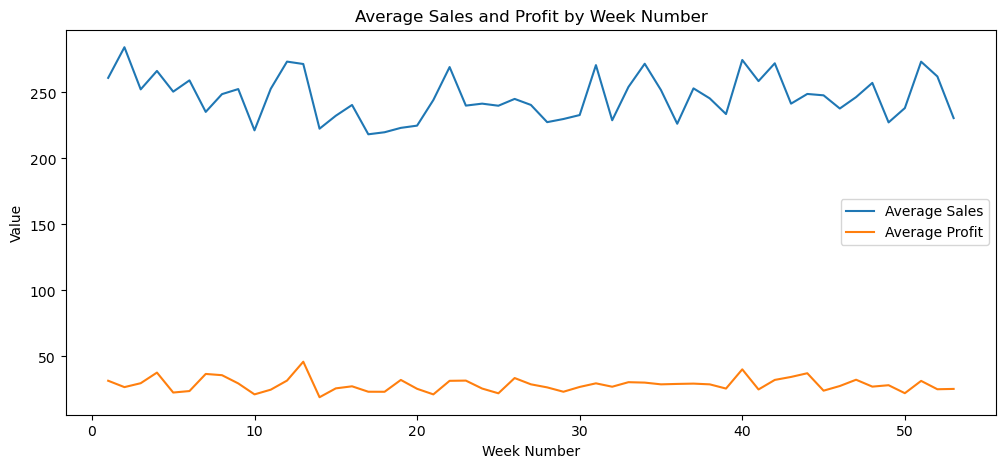

In [34]:
# Week Number vs Sales/Profit
week_metrics = df.groupby('weeknum')[['Sales', 'Profit']].mean().reset_index()
plt.figure(figsize=(12,5))
plt.plot(week_metrics['weeknum'], week_metrics['Sales'],label='Average Sales')
plt.plot(week_metrics['weeknum'], week_metrics['Profit'],label='Average Profit')
plt.title('Average Sales and Profit by Week Number')
plt.xlabel('Week Number')
plt.ylabel('Value')
plt.legend()
plt.show()

In [35]:
# Certain weeks exhibit higher sales and profit levels, indicates possible seasonal or promotional effects.

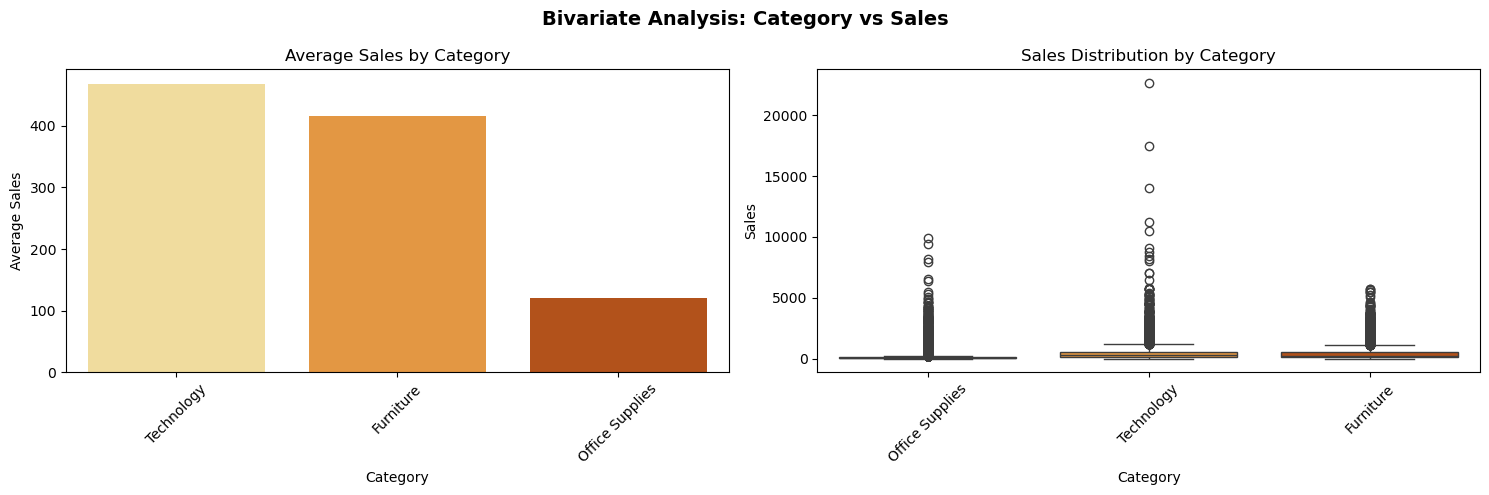

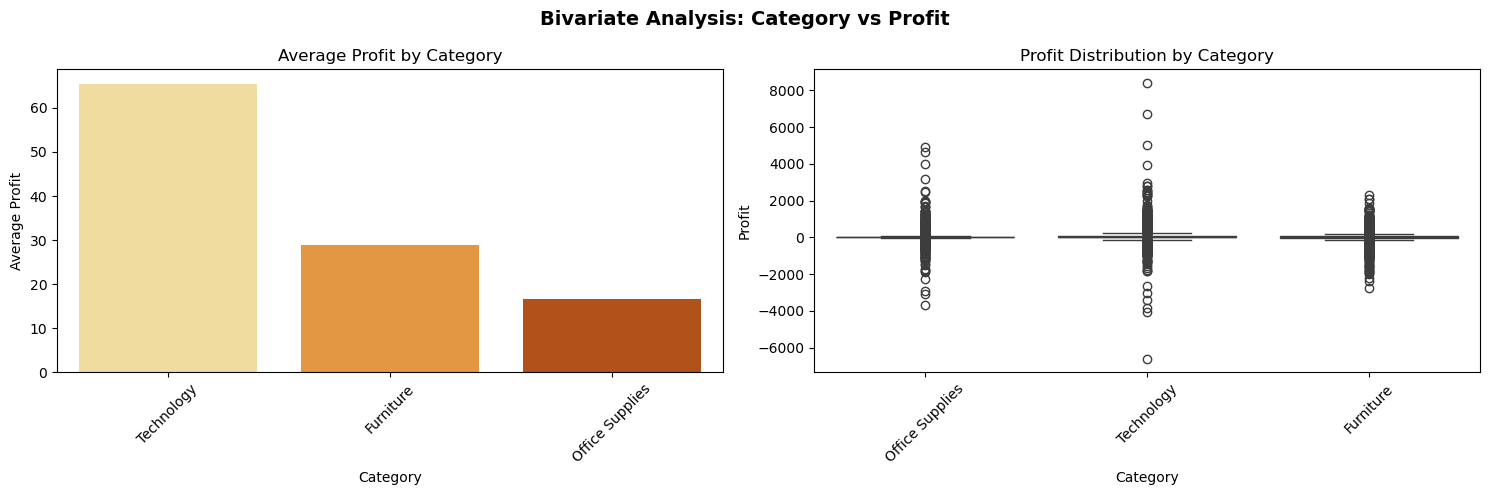

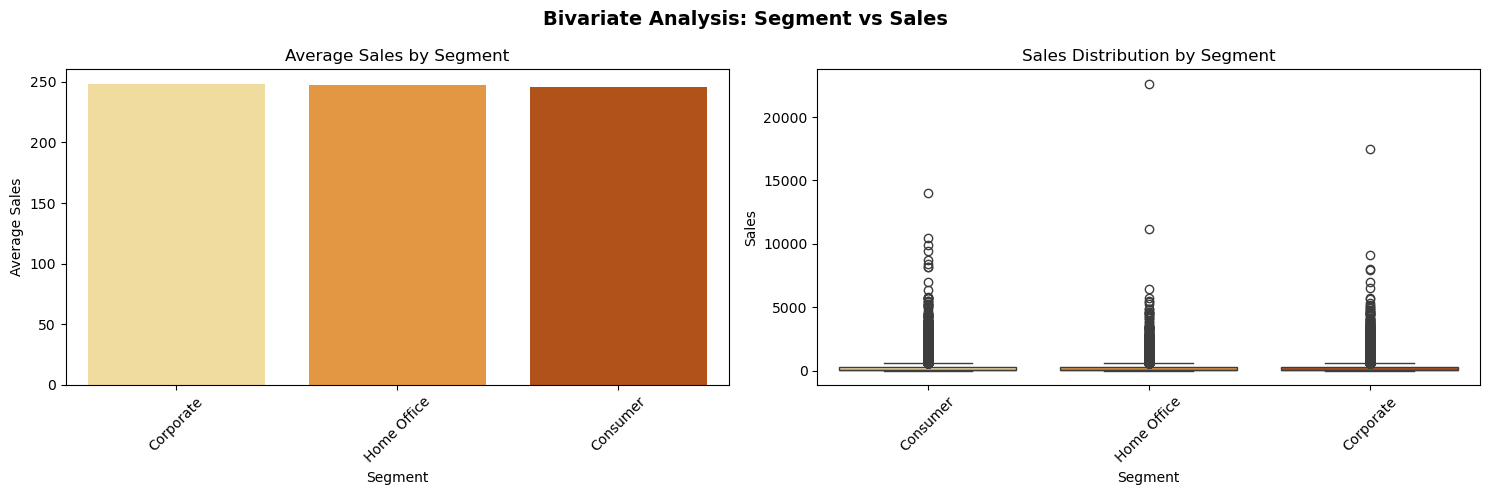

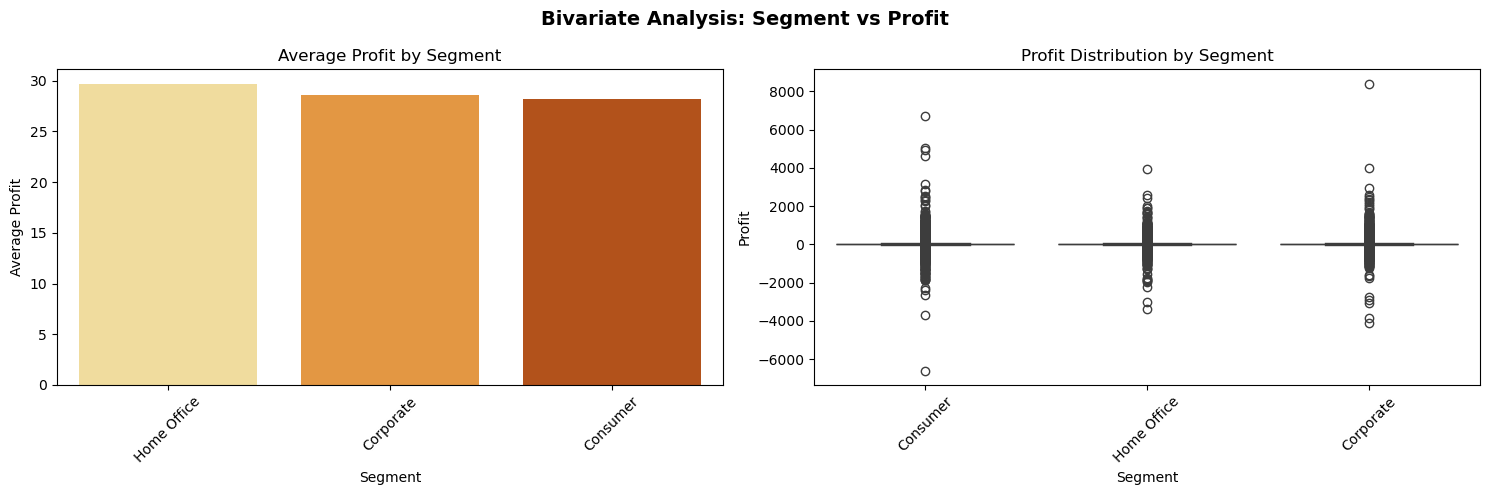

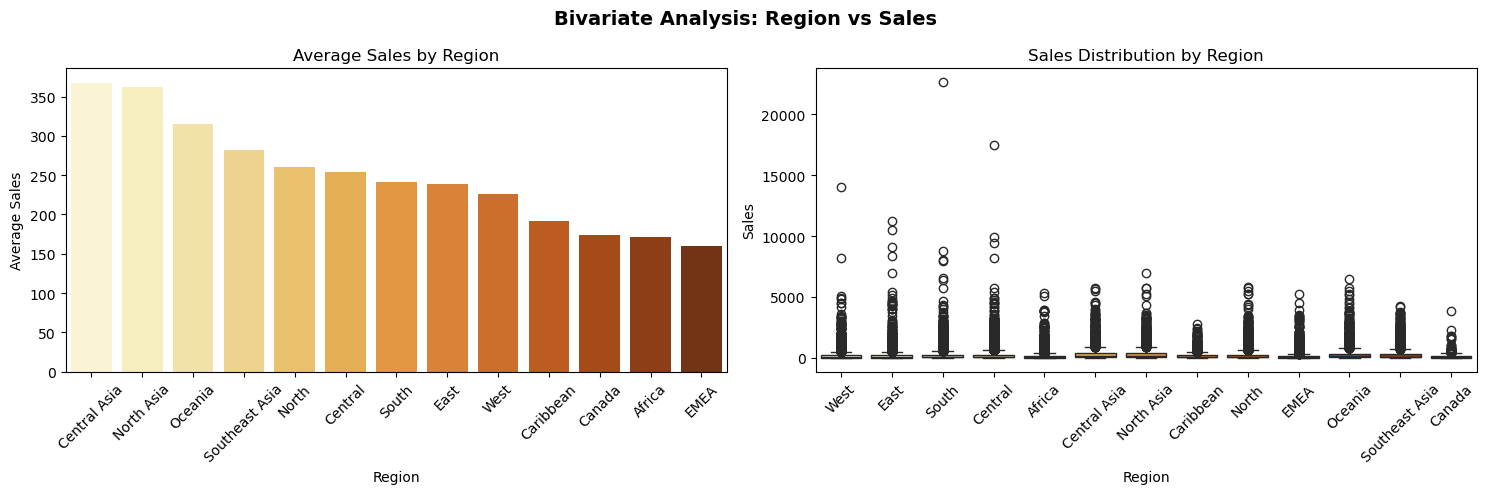

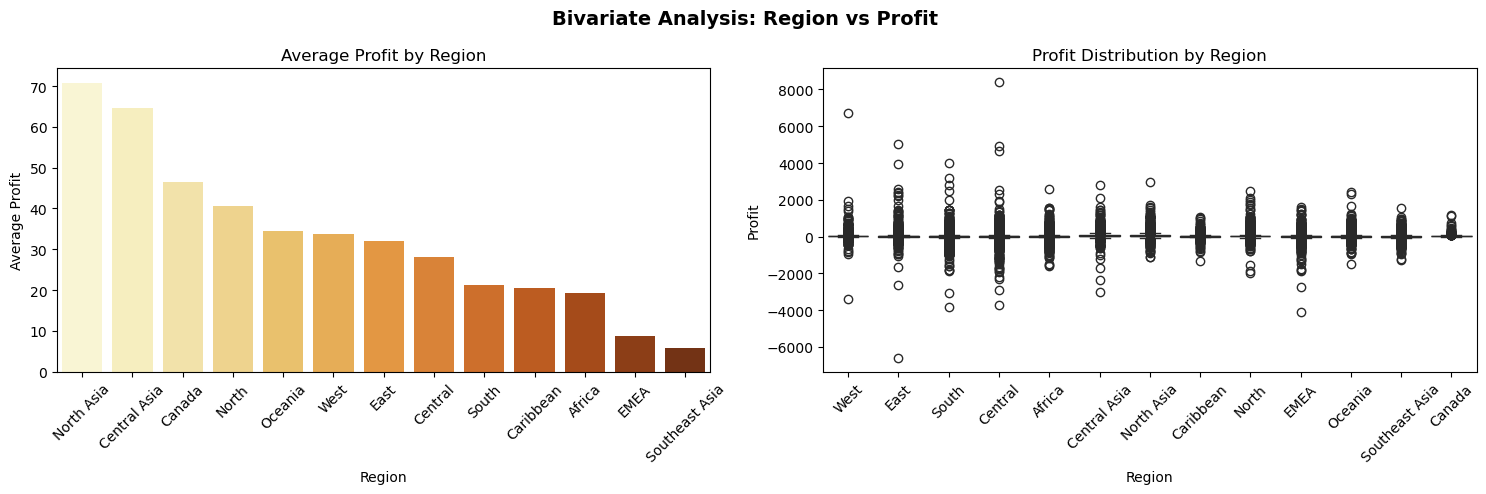

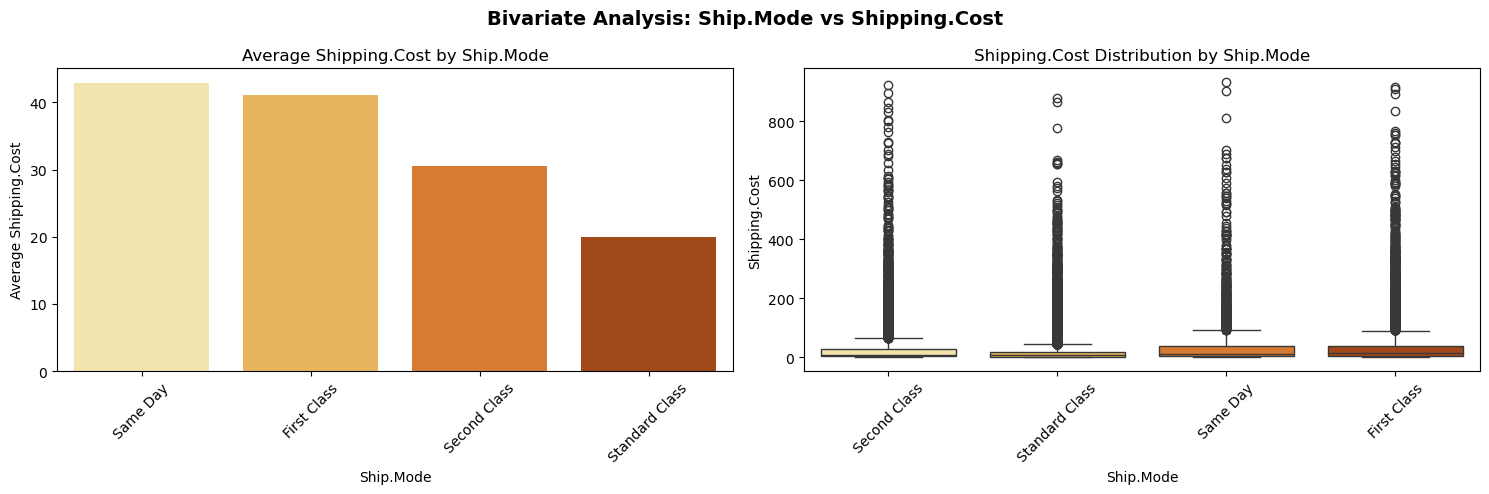

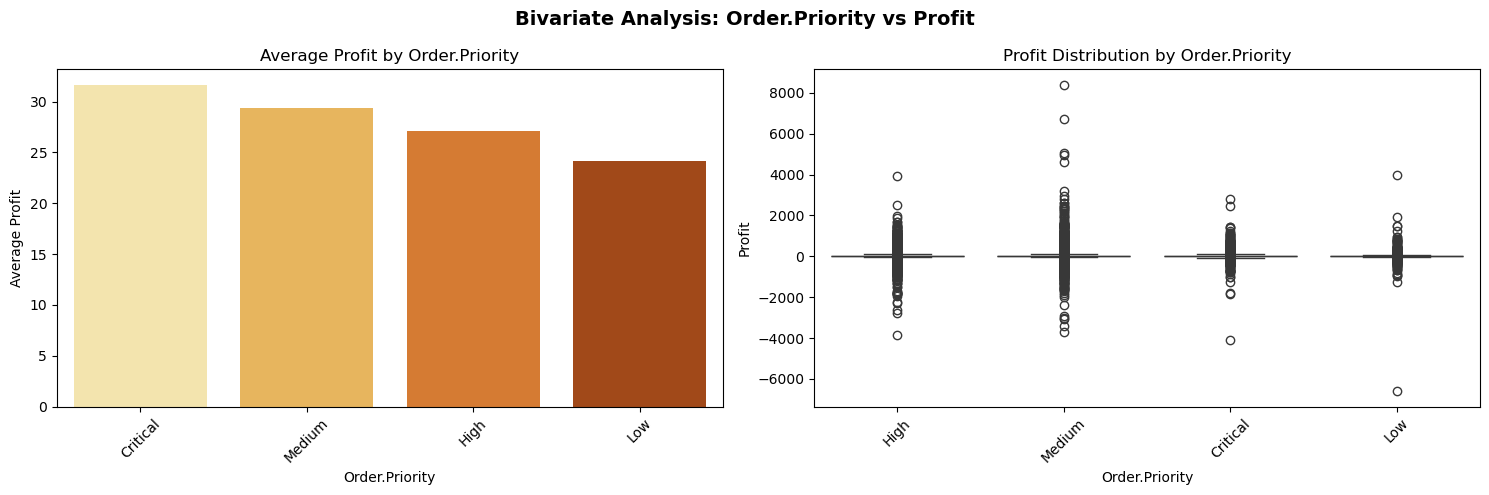

In [36]:
# BIVARIATE ANALYSIS CATEGORICAL vs NUMERICAL FEATURES
pairs = [
    ('Category', 'Sales'),
    ('Category', 'Profit'),
    ('Segment', 'Sales'),
    ('Segment', 'Profit'),
    ('Region', 'Sales'),
    ('Region', 'Profit'),
    ('Ship.Mode', 'Shipping.Cost'),
    ('Order.Priority', 'Profit')
]

for cat_col, num_col in pairs:
    fig, axes = plt.subplots(1, 2, figsize=(15,5))
    avg_values = (df.groupby(cat_col)[num_col].mean().sort_values(ascending=False))
    sns.barplot(x=avg_values.index,y=avg_values.values,hue=avg_values.index,palette='YlOrBr',legend=False,ax=axes[0])
    axes[0].set_title(f'Average {num_col} by {cat_col}')
    axes[0].set_xlabel(cat_col)
    axes[0].set_ylabel(f'Average {num_col}')
    axes[0].tick_params(axis='x', rotation=45)
    sns.boxplot(data=df,x=cat_col,y=num_col,hue=cat_col,palette='YlOrBr',legend=False,ax=axes[1])
    axes[1].set_title(f'{num_col} Distribution by {cat_col}')
    axes[1].set_xlabel(cat_col)
    axes[1].set_ylabel(num_col)
    axes[1].tick_params(axis='x', rotation=45)
    plt.suptitle(f'Bivariate Analysis: {cat_col} vs {num_col}',fontsize=14,fontweight='bold')
    plt.tight_layout()
    plt.show()

In [37]:
#Profit by Category
profit_summary = df.groupby('Category')['Profit'].agg(
    Median='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

profit_summary['IQR'] = profit_summary['Q3'] - profit_summary['Q1']

print(profit_summary.sort_values('Median', ascending=False))

                  Median      Q1     Q3     IQR
Category                                       
Technology       29.9400   0.500  98.85  98.350
Furniture        15.5022 -12.175  69.36  81.535
Office Supplies   6.5538   0.450  20.58  20.130


In [38]:
# highest median profit -- Technology (Median Profit = 29.94)
# category has the lowest median profit --Office Supplies (Median Profit = 6.55)
#category shows the widest spread (largest IQR) in Profit -- Technology (IQR = 98.35)
#What does this suggest about profit consistency?
#Technology has the largest IQR, indicating less consistent profitability and greater variation in profits.
#Office Supplies has the smallest IQR, indicating more stable and predictable profits.
#Furniture falls in between, showing moderate variability.

In [39]:
#Sales by Category: Which category has the highest median sales? Does it also have the highest median profit? 
#Furniture (Median Sales ≈ 85.05) has the hieghest median sales
#But it donot have highest median profit 
#This indicates that higher sales do not necessarily translate into higher profits.

In [40]:
# Profit by segement and IQR by Segment
segment_profit_summary = df.groupby('Segment')['Profit'].agg(Median='median',Q1=lambda x: x.quantile(0.25),Q3=lambda x: x.quantile(0.75))
segment_profit_summary['IQR'] = (segment_profit_summary['Q3']- segment_profit_summary['Q1'])
print(segment_profit_summary)

             Median   Q1       Q3      IQR
Segment                                   
Consumer     9.1800  0.0  36.6525  36.6525
Corporate    9.3152  0.0  36.9450  36.9450
Home Office  9.3200  0.0  37.0800  37.0800


In [41]:
#Profit by Segment: Which segment has the highest median profit? Which segment has the most negative/low profit outliers?
# Consumer Segment (Median Profit ≈ 9.24) has the highest median profit
# Consumer Segment also has the most negative/low profit outliers

In [42]:
# Sales by Segment
median_sales = (df.groupby('Segment')['Sales'].median().sort_values(ascending=False))
print(median_sales)

Segment
Consumer       85.0
Corporate      85.0
Home Office    85.0
Name: Sales, dtype: float64


In [43]:
# Sales by Segment: Which segment has the highest median sales? Is the profit pattern consistent with sales?
# Consumer Segment (Median Sales ≈ 52.97) has the highest median sales
#Yes, profit pattern consistent with sales and it can extent largly.

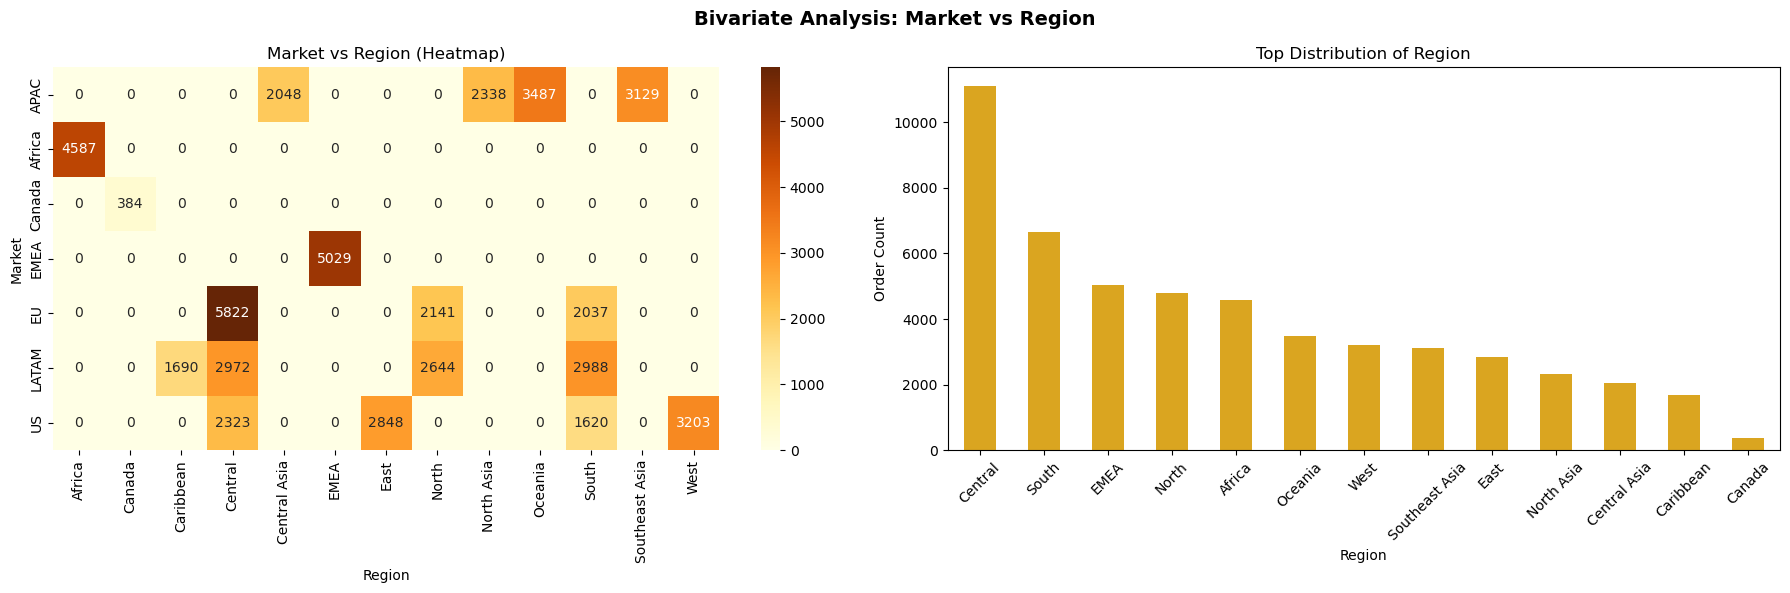

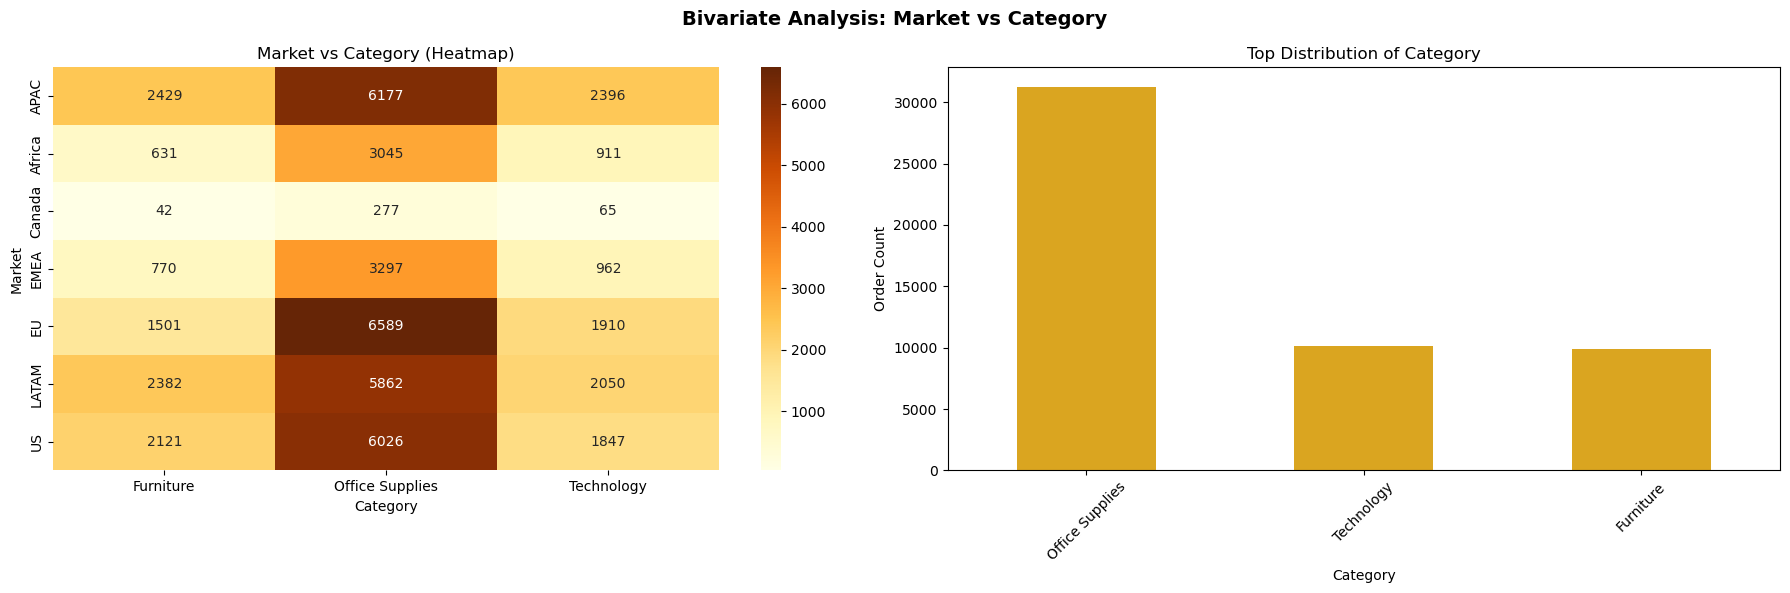

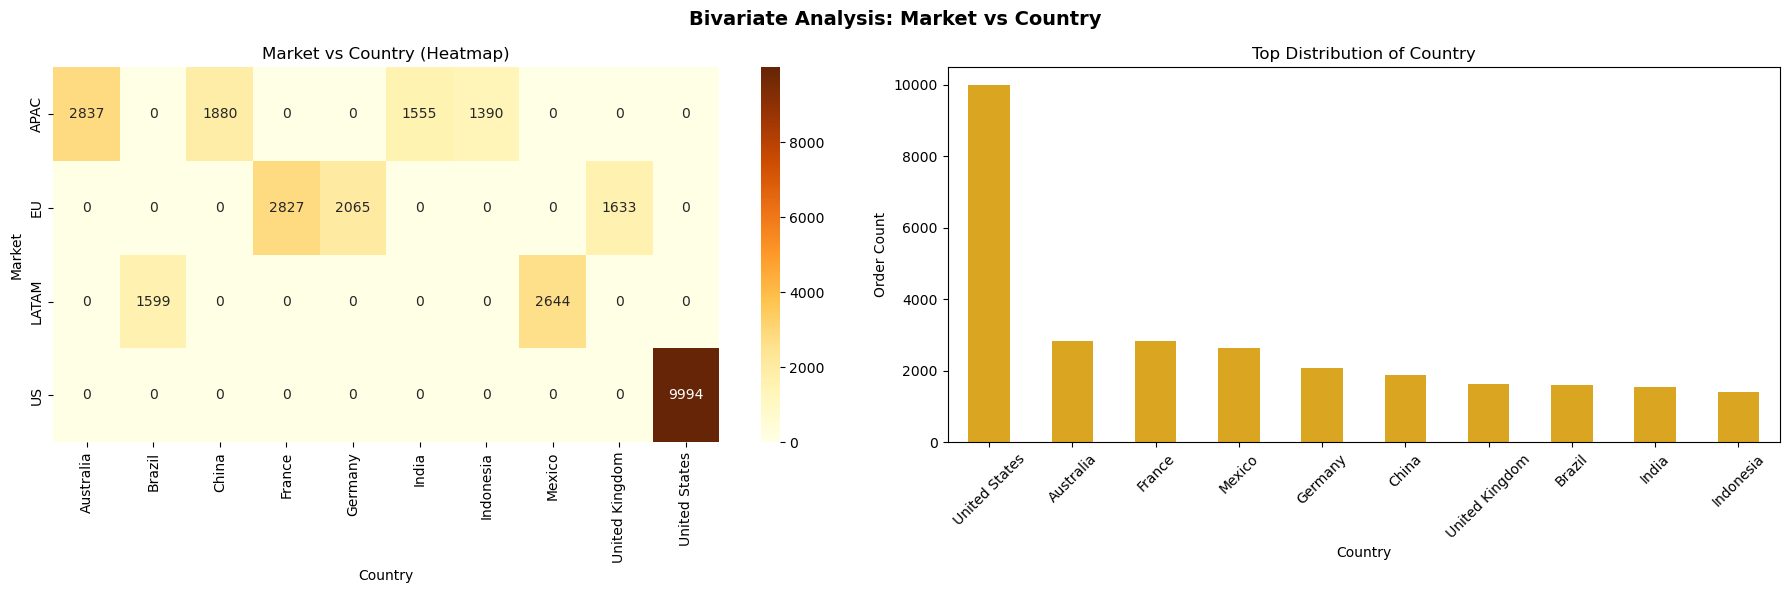

In [44]:
features = [
    'Region',
    'Category',
    'Country'
]

for feature in features:

    # --------------------------------
    # Handle Country Separately
    # --------------------------------
    if feature == 'Country':

        top_countries = (
            df['Country']
            .value_counts()
            .head(10)
            .index
        )

        temp_df = df[
            df['Country'].isin(top_countries)
        ]

        cross_tab = pd.crosstab(
            temp_df['Market'],
            temp_df['Country']
        )

    else:

        cross_tab = pd.crosstab(
            df['Market'],
            df[feature]
        )

    # --------------------------------
    # Visualization
    # --------------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=(18, 6)
    )

    # Heatmap
    sns.heatmap(
        cross_tab,
        annot=True,
        fmt='d',
        cmap='YlOrBr',
        ax=axes[0]
    )

    axes[0].set_title(
        f'Market vs {feature} (Heatmap)'
    )

    # Bar Chart
    cross_tab.sum(axis=0).sort_values(
        ascending=False
    ).plot(
        kind='bar',
        color='goldenrod',
        ax=axes[1]
    )

    axes[1].set_title(
        f'Top Distribution of {feature}'
    )

    axes[1].set_ylabel('Order Count')
    axes[1].tick_params(
        axis='x',
        rotation=45
    )

    plt.suptitle(
        f'Bivariate Analysis: Market vs {feature}',
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

In [45]:
#Is the Market is not randomly spread across all Regions?  
# No, the Market feature is not randomly spread across all Regions.
#The Market vs Region heatmap shows higher concentrations in particular market-region combinations.
#Some regions contribute significantly more orders to certain markets than others.
#Several market-region combinations have very low or zero counts.

In [46]:
#Which country has negligible office supply orders? 
# Armenia
#Bahrain
#Swaziland
#Eritrea
office_supply_orders = (
    df[df['Category'] == 'Office Supplies']['Country']
    .value_counts()
    .sort_values()
)

print(office_supply_orders.head(10))

Country
Armenia              1
Bahrain              1
Swaziland            1
Eritrea              1
Chad                 2
Equatorial Guinea    2
Tajikistan           2
Lesotho              2
Slovenia             2
Guadeloupe           2
Name: count, dtype: int64


In [ ]:
# What are the most useful insights?
#Markets are geographically segmented and not randomly distributed across regions.
#A small number of countries contribute a large share of orders, indicating geographic concentration of business activity.
#Category demand varies across markets, suggesting that customer preferences differ by region and market.